# Dallas CIP Parser v2

Parses all PDFs in `Dallas/PDF/` and writes one CSV per PDF into `Dallas/CSV/`.

## Format families
| Family | PDFs | Key signal |
|--------|------|-----------|
| A | 2007-2017 | Key Focus Area column |
| B | 2018 | ACTIVITY column, 270° rotation |
| C | 2019-2025 | Funding Source column |

## Added in this revision
- Currency unit detection per PDF (pitfall #11)
- Per-column null rate tracking (pitfall #15)
- Cell 11: spot-check 3 projects/PDF with page render + auto-flag
- Cell 12: validation markdown report

## Bug fixes (v2.1)
- `clean_cell`: hyphen repair uses `(?<=\w)-\n` lookbehind — separator dashes no longer stripped
- `split_name_id`: handles prefix-format codes (`V767_name`) in addition to suffix format (`name - V767`)
- Cell 11 name-match: uses table column-0 scan instead of `extract_text()` — works correctly for rotated pages and multi-column layouts

## Cell 1 - Imports & paths

In [43]:
import re
import warnings
from pathlib import Path
from collections import defaultdict

import pdfplumber
import pandas as pd

try:
    from PIL import Image as PILImage
    HAS_PIL = True
except ImportError:
    HAS_PIL = False

warnings.filterwarnings('ignore')

SCRIPTS_DIR = Path('.').resolve()
CITY_DIR    = SCRIPTS_DIR.parent / 'Dallas'
PDF_DIR     = CITY_DIR / 'PDF'
CSV_DIR     = CITY_DIR / 'CSV'
CSV_DIR.mkdir(exist_ok=True)

FIXED_COLS = [
    'cip_year', 'project_type', 'source_page', 'department',
    'project_name', 'project_id', 'address_location',
    'start_year', 'end_year',
    'project_description', 'project_justification',
    'previous_appropriations', 'project_total',
]

print('Paths OK.')
print(f"  PDF_DIR : {PDF_DIR}")
print(f"  CSV_DIR : {CSV_DIR}")
print('PDFs found:', sorted(p.name for p in PDF_DIR.glob('*.pdf')))

Paths OK.
  PDF_DIR : C:\Users\vince\Documents\GitHub\CIPBD\Dallas\PDF
  CSV_DIR : C:\Users\vince\Documents\GitHub\CIPBD\Dallas\CSV
PDFs found: ['2007.pdf', '2008.pdf', '2010.pdf', '2011.pdf', '2012.pdf', '2013.pdf', '2014.pdf', '2015.pdf', '2016.pdf', '2017.pdf', '2018.pdf', '2019.pdf', '2020.pdf', '2021.pdf', '2022.pdf', '2023.pdf', '2024.pdf', '2025.pdf']


## Cell 2 - Shared extraction utilities

In [44]:
# ── 270° rotation fix ────────────────────────────────────────────────────────
def fix_270_table(raw_table):
    """Transpose rows<->cols, reverse column order, reverse each cell string."""
    if not raw_table:
        return []
    max_cols   = max(len(r) for r in raw_table)
    padded     = [list(r) + [''] * (max_cols - len(r)) for r in raw_table]
    transposed = list(map(list, zip(*padded)))
    return [
        [str(c)[::-1] if c else '' for c in reversed(row)]
        for row in transposed
    ]


def get_page_tables(pg):
    raw = pg.extract_tables() or []
    return [fix_270_table(t) for t in raw] if pg.rotation == 270 else raw


def clean_cell(c):
    if c is None:
        return ''
    # Repair hyphenated line-wraps (pitfall #2).
    # Lookbehind (?<=\w) ensures only true continuation hyphens are removed
    # (e.g. "multi-\nplatform" -> "multiplatform"), not separator dashes
    # (e.g. "Pl -\nFa" stays "Pl - Fa", not "Pl Fa").
    s = re.sub(r'(?<=\w)-\n', '', str(c))
    s = re.sub(r'\s+', ' ', s)
    return s.strip()


# ── Number parsing ────────────────────────────────────────────────────────────
_NULL_VALS = {'', '-', 'n/a', 'na', 'tbd', 'zero', 'various', 'ongoing'}

def parse_number(s):
    if s is None:
        return None
    s = re.sub(r'[$,]', '', str(s).strip())
    s = re.sub(r'^\((.+)\)$', r'-\1', s)      # (1,234) -> -1234
    if s.lower() in _NULL_VALS or s in ('\u2014', '\u2013', '\u2212'):
        return 0.0
    try:
        return float(s)
    except ValueError:
        return None


# ── Currency unit detection (pitfall #11) ─────────────────────────────────────
_CURRENCY_PATTERNS = [
    (re.compile(r'\(\$K\)',                         re.I), '$K',   1_000),
    (re.compile(r'\(\$000\)',                       re.I), '$000', 1_000),
    (re.compile(r'amounts?\s+in\s+thousands?',       re.I), '$K',   1_000),
    (re.compile(r'in\s+thousands?\s+of\s+dollars?', re.I), '$K',   1_000),
    (re.compile(r'\(thousands?\)',                   re.I), '$K',   1_000),
]

def detect_currency_unit(pdf_path):
    """Scan first 10 pages for currency scale markers. Dallas default: $K (thousands)."""
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for pg in pdf.pages[:10]:
                txt = (pg.extract_text() or '').replace('\n', ' ')
                for rgx, label, factor in _CURRENCY_PATTERNS:
                    if rgx.search(txt):
                        return label, factor
    except Exception:
        pass
    return '$K', 1_000   # Dallas default


# ── Department banner ─────────────────────────────────────────────────────────
_DEPT_SKIP = {
    'OVERVIEW', 'MISSION', 'PROJECT LIST', 'SOURCE OF FUNDS',
    'USE OF FUNDS', 'SUMMARY', 'CAPITAL IMPROVEMENT PROGRAM',
    'SERVICE DESCRIPTIONS', 'OPERATING AND MAINTENANCE COSTS',
    'HIGHLIGHTED ACCOMPLISHMENTS', 'HIGHLIGHTED OBJECTIVES',
    'SERVICE FUTURE COSTS', 'FUTURE COSTS', 'CITY OF DALLAS',
}
_DEPT_RE_CAPS  = re.compile(r'^[A-Z][A-Z ,&/\-]+$')
_DEPT_RE_LOWER = re.compile(r'^[A-Za-z][a-zA-Z ,&/\-]+$')

def get_department(pg):
    """Extract department from page header. Handles 270-deg rotation and 2023+ lowercase headers."""
    txt = pg.extract_text() or ''
    lines = [
        (ln[::-1] if pg.rotation == 270 else ln).strip()
        for ln in txt.split('\n') if ln.strip()
    ]
    for idx, line in enumerate(lines[:6]):
        line = re.sub(r'\bCAPITAL\b.*', '', line).strip()
        line = re.sub(r'\bIMPROVEMENTS?\b.*', '', line).strip().rstrip(',')
        if not line:
            continue
        if _DEPT_RE_CAPS.match(line) and len(line) > 4 and line not in _DEPT_SKIP:
            return line
        if (
            idx <= 1
            and _DEPT_RE_LOWER.match(line)
            and 9 <= len(line) <= 70
            and len(line.split()) >= 4
            and not re.search(r'[\d$%]', line)
            and line.upper() not in _DEPT_SKIP
        ):
            return line.upper()
    return ''


print('Shared utilities loaded.')

Shared utilities loaded.


## Cell 3 - Step 1: Page classification

In [45]:
_PROJECT_HEADER_RE = re.compile(r'^(Project(s| Name)?|ACTIVITY)$', re.I)


def is_project_page(pg):
    for table in get_page_tables(pg):
        if not table or len(table) < 2:
            continue
        for row in table[:5]:
            first = next((clean_cell(c) for c in row if clean_cell(c)), '')
            if _PROJECT_HEADER_RE.match(first):
                return True
    return False


def classify_pages(pdf_path):
    page_types = {}
    with pdfplumber.open(pdf_path) as pdf:
        for i, pg in enumerate(pdf.pages):
            page_types[i + 1] = 'project' if is_project_page(pg) else 'other'
    return page_types


pdf_files = sorted(PDF_DIR.glob('*.pdf'))
page_map  = {}

print(f"{'PDF':<12} {'Total pgs':>10} {'Project pgs':>12} {'Other pgs':>10}")
print('-' * 48)

for p in pdf_files:
    pt = classify_pages(p)
    page_map[p.stem] = pt
    n_proj  = sum(1 for v in pt.values() if v == 'project')
    n_other = len(pt) - n_proj
    print(f'{p.name:<12} {len(pt):>10} {n_proj:>12} {n_other:>10}')

PDF           Total pgs  Project pgs  Other pgs
------------------------------------------------
2007.pdf            314          239         75
2008.pdf            295          220         75
2010.pdf            250          180         70
2011.pdf            216          146         70
2012.pdf            232          164         68
2013.pdf            224          155         69
2014.pdf            196          129         67
2015.pdf            180          113         67
2016.pdf            164          104         60
2017.pdf            140           46         94
2018.pdf            234           47        187
2019.pdf            170          119         51
2020.pdf             90           48         42
2021.pdf            215          160         55
2022.pdf            212          158         54
2023.pdf            174          110         64
2024.pdf            198          141         57
2025.pdf            210          152         58


## Cell 4 - Step 2: Format detection

In [46]:
def _get_header_cells(pdf_path, page_type_map):
    project_pages = sorted(pn for pn, t in page_type_map.items() if t == 'project')
    with pdfplumber.open(pdf_path) as pdf:
        for pg_num in project_pages[:5]:
            pg = pdf.pages[pg_num - 1]
            for table in get_page_tables(pg):
                if not table:
                    continue
                for row in table[:5]:
                    cells = [clean_cell(c) for c in row]
                    first = next((c for c in cells if c), '')
                    if _PROJECT_HEADER_RE.match(first):
                        return cells
    return []


def detect_format(header_cells):
    non_empty = [c for c in header_cells if c]
    if not non_empty:
        return 'unknown'
    if non_empty[0].upper() == 'ACTIVITY':
        return 'B'
    third = non_empty[2] if len(non_empty) > 2 else ''
    if 'key focus' in third.lower():
        return 'A'
    if 'funding' in third.lower() or 'source' in third.lower():
        return 'C'
    return 'unknown'


format_map = {}
families   = defaultdict(list)

print(f"{'PDF':<12} {'Format':>8}  Header (first 5 non-empty cells)")
print('-' * 90)

for p in pdf_files:
    hdr = _get_header_cells(p, page_map[p.stem])
    fmt = detect_format(hdr)
    format_map[p.stem] = fmt
    families[fmt].append(p.stem)
    preview = ' | '.join(c[:20] for c in hdr if c)[:5 * 22]
    print(f'{p.name:<12} {fmt:>8}  {preview}')

print()
for fmt, stems in sorted(families.items()):
    print(f'Format {fmt}: {stems}')

PDF            Format  Header (first 5 non-empty cells)
------------------------------------------------------------------------------------------
2007.pdf            A  Project | Service | Key Focus Area | Council District | Funding Source | Budget as of 06/30/0 | Spent or Commi
2008.pdf            A  Project | Service | Key Focus Area | Council District | Funding Source | Budget as of 06/30/0 | Spent or Commi
2010.pdf            A  Project | Service | Key Focus Area | Council District | Funding Source | Budget as of 05/31/1 | Spent or Commi
2011.pdf            A  Project | Service | Key Focus Area | Council District | Funding Source | Budget as of 06/30/1 | Spent or Commi
2012.pdf            A  Project | Service | Key Focus Area | Council District | Funding Source | Budget as of 05/31/1 | Spent or Commi
2013.pdf            A  Project | Service | Key Focus Area | Council District | Funding Source | Budget as of 04-30-1 | Spent or Commi
2014.pdf            A  Project | Service | Key Fo

## Cell 5 - Column-header normalisation

Maps raw header text to canonical tags. FY columns map to year_YYYY using the start year.

In [47]:
_HEADER_MAP = [
    ('project name', 'project_name'),
    ('projects',     'project_name'),
    ('project',      'project_name'),
    ('activity',     'project_name'),
    # completion date entries BEFORE 'service' to avoid mis-tagging 'In Service Date'
    ('in service',      'completion_date'),
    ('comp. date',      'completion_date'),
    ('completion date', 'completion_date'),
    ('amended date',    'completion_date'),
    ('est. comp',       'completion_date'),
    ('service',      'project_type'),
    ('key focus',    '_key_focus'),
    ('funding source', 'funding_source'),
    ('fund',           'funding_source'),
    ('council',      'council_district'),
    ('unit number',  'unit_number'),
    ('budget itd',     'previous_appropriations'),
    ('budget as of',   'previous_appropriations'),
    ('budget balance', 'previous_appropriations'),
    ('budget',         'previous_appropriations'),
    ('spent',               '_spent'),
    ('capital expenditure', '_spent'),
    ('expenditure',         '_spent'),
    ('remaining',    '_remaining'),
    ('total project cost',   'project_total'),
    ('total estimated cost', 'project_total'),
    ('total projected',      'project_total'),
    ('total',                'project_total'),
    ('future cost', '_future_costs'),
]

_FY_RE = re.compile(r'FY\s*(\d{4})[\s\-\u2013](\d{2,4})', re.I)


def normalise_header(raw_headers):
    """Map raw header text to canonical tags. FY columns -> year_YYYY (start year)."""
    tags     = []
    fy_years = []
    used     = set()
    for raw in raw_headers:
        h = clean_cell(raw).lower()
        m = _FY_RE.search(h)
        if m:
            yr  = int(m.group(1))
            tag = f'year_{yr}'
            if yr not in fy_years:
                fy_years.append(yr)
            tags.append(tag)
            continue
        matched = None
        for pattern, tag in _HEADER_MAP:
            if pattern in h:
                if tag in used:
                    continue
                matched = tag
                used.add(tag)
                break
        tags.append(matched or f'_skip_{len(tags)}')
    return tags, sorted(set(fy_years))


def is_project_table(tags):
    return 'project_name' in tags and any(
        t in tags for t in ('previous_appropriations', 'project_total', '_spent')
        or t.startswith('year_') for t in tags
    )


print('Header normalisation loaded.')

Header normalisation loaded.


## Cell 6 - Project-name and date utilities

In [48]:
_PID_RE        = re.compile(r'[-\s]+([A-Z]{1,2}[0-9][A-Z0-9]{0,5})\s*$')
_PID_PREFIX_RE = re.compile(r'^([A-Z]{1,2}[0-9][A-Z0-9]{0,5})_(.+)')


def split_name_id(raw):
    """
    Extract (project_name, project_id) from a raw name cell.

    Two formats are handled:
      Suffix  (2019-2025): "Street Name - V933"  -> ('Street Name', 'V933')
      Prefix  (2020):      "V767_Street Name"     -> ('Street Name', 'V767')
    """
    name = clean_cell(raw)
    # Suffix format: code at end, separated by dash/space
    m = _PID_RE.search(name)
    if m:
        return name[:m.start()].strip().rstrip('-').strip(), m.group(1)
    # Prefix format: code at start, separated by underscore (e.g. 2020 PDFs)
    m = _PID_PREFIX_RE.match(name)
    if m:
        return m.group(2).strip(), m.group(1)
    return name, ''


def extract_end_year(date_str):
    if not date_str:
        return ''
    d = str(date_str).strip()
    m = re.search(r'\b(20\d{2}|19\d{2})\b', d)
    if m:
        return int(m.group(1))
    m = re.search(r'/(\d{2})$', d)
    if m:
        yy = int(m.group(1))
        return 2000 + yy if yy < 50 else 1900 + yy
    return ''


_ROW_SKIP_STARTS = (
    'project', 'activity', 'total', 'grand total', 'department total',
    'source of funds', 'use of funds',
)
_ROW_SKIP_EXACT = re.compile(
    r'^(Project(s| Name)?|ACTIVITY|Service(s)?|Funding Source)$', re.I
)


def build_row(row_cells, tags, fy_years, cip_year, department, pg_num):
    """Convert a data row into a project record dict. Returns None for non-project rows."""
    cell = {}
    for i, tag in enumerate(tags):
        if tag not in cell:   # first-wins for duplicate tags
            cell[tag] = clean_cell(row_cells[i]) if i < len(row_cells) else ''

    raw_name = cell.get('project_name', '')
    if not raw_name:
        return None
    if any(raw_name.lower().startswith(f) for f in _ROW_SKIP_STARTS):
        return None
    if _ROW_SKIP_EXACT.match(raw_name):
        return None

    budget_val = parse_number(cell.get('previous_appropriations', ''))
    total_val  = parse_number(cell.get('project_total', ''))
    year_vals  = [parse_number(cell.get(f'year_{y}', '')) for y in fy_years]
    has_data   = (
        (budget_val not in (None, 0.0))
        or (total_val  not in (None, 0.0))
        or any(v not in (None, 0.0) for v in year_vals)
    )
    if not has_data:
        return None

    name, pid = split_name_id(raw_name)
    if not pid and cell.get('unit_number', ''):
        m = re.search(r'U_([A-Z0-9]+)', cell['unit_number'])
        if m:
            pid = m.group(1)

    def num(tag):
        v = parse_number(cell.get(tag, ''))
        return v if v is not None else ''

    rec = {
        'cip_year':               cip_year,
        'project_type':           cell.get('project_type', ''),
        'source_page':            pg_num,
        'department':             department,
        'project_name':           name,
        'project_id':             pid,
        'address_location':       '',
        'start_year':             '',
        'end_year':               extract_end_year(cell.get('completion_date', '')),
        'project_description':    '',
        'project_justification':  '',
        'previous_appropriations': num('previous_appropriations'),
        'project_total':          num('project_total'),
    }
    for yr in fy_years:
        rec[f'year_{yr}'] = num(f'year_{yr}')
    return rec


assert split_name_id('Fire Station #46 - VG02')               == ('Fire Station #46', 'VG02')
assert split_name_id('2010 CO - IC70')                         == ('2010 CO', 'IC70')
assert split_name_id('Central Library')                        == ('Central Library', '')
assert split_name_id('V767_Whittier Ave from San Benito Way')  == ('Whittier Ave from San Benito Way', 'V767')
assert split_name_id('V199_Anzio Cir from Garapan Dr')         == ('Anzio Cir from Garapan Dr', 'V199')
assert extract_end_year('09/2026')  == 2026
assert extract_end_year('4th/07')   == 2007
assert extract_end_year('Ongoing')  == ''
print('Utilities OK.')

Utilities OK.


## Cell 7 - Format A parser (2007-2017)

In [49]:
def _find_header_row(table):
    """Locate the column-header row (skips section-title prepended rows)."""
    for i, row in enumerate(table[:5]):
        cells = [clean_cell(c) for c in row]
        first = next((c for c in cells if c), '')
        if _PROJECT_HEADER_RE.match(first):
            tags, fy_years = normalise_header(cells)
            if is_project_table(tags):
                return i, tags, fy_years
    return None, [], []


def parse_format_a(pdf_path, page_type_map):
    stem     = pdf_path.stem
    cip_year = int(stem) if stem.isdigit() else None
    projects = []
    all_fy   = []
    dept     = ''

    with pdfplumber.open(pdf_path) as pdf:
        for i, pg in enumerate(pdf.pages):
            pg_num = i + 1
            d = get_department(pg)
            if d:
                dept = d
            if page_type_map.get(pg_num) != 'project':
                continue
            for table in get_page_tables(pg):
                if not table:
                    continue
                hdr_idx, tags, fy_years = _find_header_row(table)
                if hdr_idx is None:
                    continue
                for yr in fy_years:
                    if yr not in all_fy:
                        all_fy.append(yr)
                for row in table[hdr_idx + 1:]:
                    rec = build_row(row, tags, fy_years, cip_year, dept, pg_num)
                    if rec:
                        projects.append(rec)

    return cip_year, projects, sorted(all_fy)


print('Format A parser ready.')

Format A parser ready.


## Cell 8 - Format B parser (2018)

In [50]:
def _build_format_b_tags(pg):
    """
    FY column labels live only in the raw page text after fix_270_table.
    Extract them by reversing each line (270-deg text), then build a fixed tag array.

    Column structure: project_name | unit_number | funding_source | council_district
                      | previous_appropriations | _spent | _remaining
                      | year_YYYY ... | project_total
    """
    txt = pg.extract_text() or ''
    readable = ' '.join(ln[::-1] for ln in txt.split('\n'))
    fy_years = sorted({int(m.group(1)) for m in _FY_RE.finditer(readable)})
    tags = [
        'project_name', 'unit_number', 'funding_source', 'council_district',
        'previous_appropriations', '_spent', '_remaining',
    ] + [f'year_{y}' for y in fy_years] + ['project_total']
    return tags, fy_years


def parse_format_b(pdf_path, page_type_map):
    stem     = pdf_path.stem
    cip_year = int(stem) if stem.isdigit() else None
    projects = []
    all_fy   = []
    dept     = ''

    with pdfplumber.open(pdf_path) as pdf:
        for i, pg in enumerate(pdf.pages):
            pg_num = i + 1
            d = get_department(pg)
            if d:
                dept = d
            if page_type_map.get(pg_num) != 'project':
                continue
            tags, fy_years = _build_format_b_tags(pg)
            if not fy_years:
                continue
            for yr in fy_years:
                if yr not in all_fy:
                    all_fy.append(yr)
            for table in get_page_tables(pg):
                if not table:
                    continue
                hdr_idx = None
                for ri, row in enumerate(table[:5]):
                    first = clean_cell(row[0]) if row else ''
                    if _PROJECT_HEADER_RE.match(first):
                        hdr_idx = ri
                        break
                if hdr_idx is None:
                    continue
                for row in table[hdr_idx + 1:]:
                    if len(row) < 2 or not clean_cell(row[1]):
                        continue  # skip section-category rows (no unit number)
                    rec = build_row(row, tags, fy_years, cip_year, dept, pg_num)
                    if rec:
                        projects.append(rec)

    return cip_year, projects, sorted(all_fy)


print('Format B parser ready.')

Format B parser ready.


## Cell 9 - Format C parser (2019-2025)

In [51]:
def parse_format_c(pdf_path, page_type_map):
    stem     = pdf_path.stem
    cip_year = int(stem) if stem.isdigit() else None
    projects = []
    all_fy   = []
    dept     = ''

    with pdfplumber.open(pdf_path) as pdf:
        for i, pg in enumerate(pdf.pages):
            pg_num = i + 1
            d = get_department(pg)
            if d:
                dept = d
            if page_type_map.get(pg_num) != 'project':
                continue
            for table in get_page_tables(pg):
                if not table:
                    continue
                hdr_idx, tags, fy_years = _find_header_row(table)
                if hdr_idx is None:
                    continue
                for yr in fy_years:
                    if yr not in all_fy:
                        all_fy.append(yr)
                for row in table[hdr_idx + 1:]:
                    rec = build_row(row, tags, fy_years, cip_year, dept, pg_num)
                    if rec:
                        projects.append(rec)

    return cip_year, projects, sorted(all_fy)


print('Format C parser ready.')

Format C parser ready.


## Cell 10 - Main loop: parse all PDFs -> write CSVs

In [52]:
PARSERS = {'A': parse_format_a, 'B': parse_format_b, 'C': parse_format_c}

all_summaries  = []
currency_units = {}

for p in pdf_files:
    stem   = p.stem
    fmt    = format_map.get(stem, 'unknown')
    parser = PARSERS.get(fmt)

    if parser is None:
        print(f"[SKIP] {p.name}: unknown format '{fmt}'")
        continue

    unit_label, unit_scale = detect_currency_unit(p)
    currency_units[stem]   = (unit_label, unit_scale)

    cip_year, projects, fy_years = parser(p, page_map[stem])

    if not projects:
        print(f"[WARN] {p.name}: no projects parsed")
        continue

    df = pd.DataFrame(projects)
    for col in FIXED_COLS:
        if col not in df.columns:
            df[col] = ''
    year_cols = sorted(c for c in df.columns if c.startswith('year_'))
    df = df.reindex(columns=FIXED_COLS + year_cols)
    df['currency_unit'] = unit_label

    out_path = CSV_DIR / f'{stem}.csv'
    df.to_csv(out_path, index=False, encoding='utf-8-sig')

    print(f"\n== {p.name}  [Format {fmt}] ({unit_label}) ==")
    for dept, grp in df.groupby('department'):
        print(f"  {dept}: {len(grp)}")

    # Null rate tracking — flag columns with >50 % empty values (pitfall #15)
    all_cols = FIXED_COLS + year_cols
    null_rates = {}
    for c in all_cols:
        if c not in df.columns:
            continue
        empty = df[c].isna() | (df[c].astype(str).str.strip().isin(['', 'nan', 'N/A', 'na']))
        null_rates[c] = empty.mean()
    high_null = {k: f'{v:.0%}' for k, v in null_rates.items() if v > 0.5}
    if high_null:
        print(f"  [null >50%]: {high_null}")

    all_summaries.append({
        'pdf':           p.name,
        'format':        fmt,
        'currency_unit': unit_label,
        'projects':      len(df),
        'fy_cols':       year_cols,
        'high_null':     high_null,
    })

print('\nDone.')
print(f"Total: {sum(s['projects'] for s in all_summaries)} projects across {len(all_summaries)} PDFs")


== 2007.pdf  [Format A] ($K) ==
  AVIATION FACILITIES: 39
  CITY FACILITIES: 267
  CONVENTION AND EVENT SERVICES FACILITIES: 13
  CULTURAL FACILITIES: 50
  ECONOMIC DEVELOPMENT PROGRAMS AND INITIATIVES: 79
  EQUIPMENT ACQUISITION: 37
  FLOOD PROTECTION AND STORM DRAINAGE: 154
  PARK AND RECREATION: 549
  STREET AND THOROUGHFARE: 1755
  TRINITY RIVER CORRIDOR: 20
  WATER UTILITIES: 63
  [null >50%]: {'project_id': '100%', 'address_location': '100%', 'start_year': '100%', 'project_description': '100%', 'project_justification': '100%'}

== 2008.pdf  [Format A] ($K) ==
  AVIATION FACILITIES: 40
  CITY FACILITIES: 256
  CONVENTION AND EVENT SERVICES FACILITIES: 16
  CULTURAL FACILITIES: 55
  ECONOMIC DEVELOPMENT PROGRAMS AND INITIATIVES: 91
  EQUIPMENT ACQUISITION: 40
  FLOOD PROTECTION AND STORM DRAINAGE: 150
  PARK AND RECREATION: 528
  STREET AND THOROUGHFARE: 1498
  TRINITY RIVER CORRIDOR: 15
  WATER UTILITIES: 59
  [null >50%]: {'project_id': '100%', 'address_location': '100%', 'start

## Cell 11 - Spot-check: 3 projects per PDF


PDF: 2007.pdf  |  3026 projects  |  sampling 3  |  $K

  Project  : Akard St. - Ross to Woodall Rodgers
  Dept     : STREET AND THOROUGHFARE  |  ID: nan
  Page     : 149  |  project_total: 2309227.0 ($K)
  Years    : {'year_2007': '346384.0', 'year_2008': '1962843.0', 'year_2009': '0.0', 'year_2010': '0.0'}


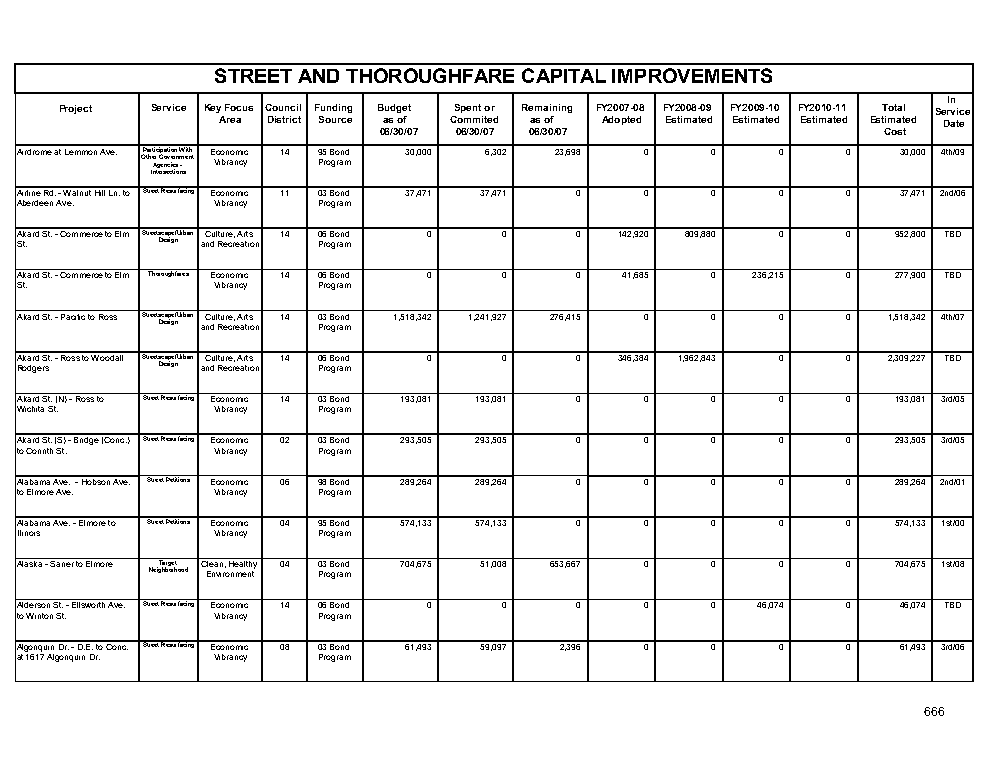

  Status   : OK

  Project  : Public Art Administration - Police Headquarters
  Dept     : CITY FACILITIES  |  ID: nan
  Page     : 40  |  project_total: 15000.0 ($K)
  Years    : {'year_2007': '0.0', 'year_2008': '0.0', 'year_2009': '0.0', 'year_2010': '0.0'}


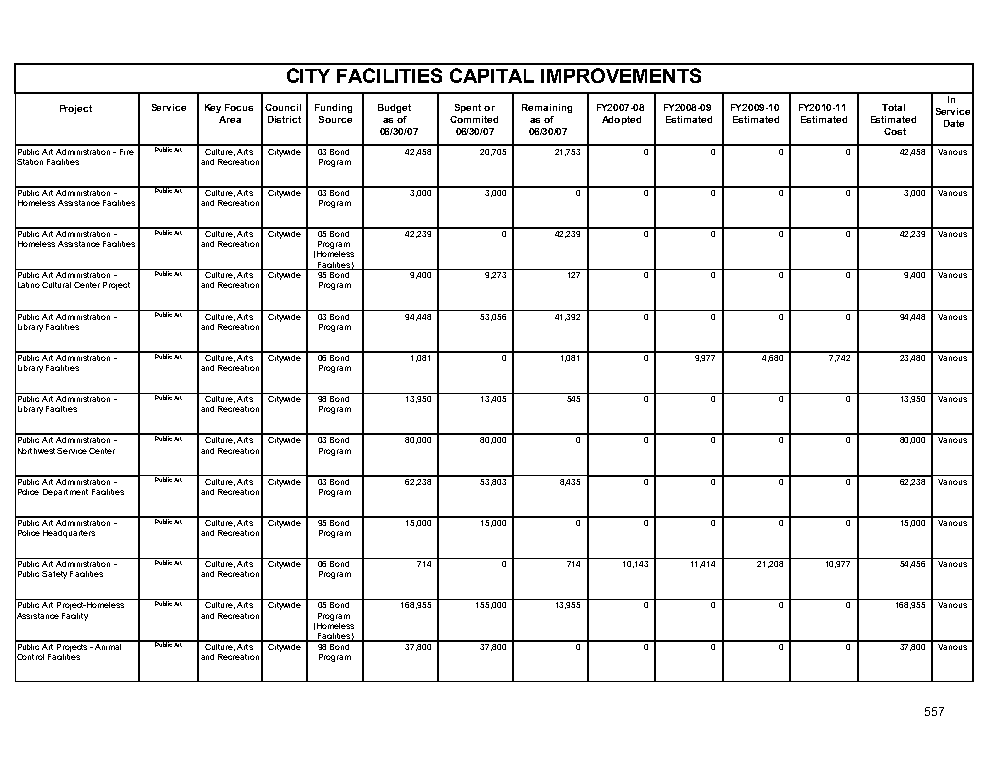

  Status   : OK

  Project  : Peavy Rd. at Redondo Dr. - Naylor St.
  Dept     : STREET AND THOROUGHFARE  |  ID: nan
  Page     : 246  |  project_total: 7618.0 ($K)
  Years    : {'year_2007': '0.0', 'year_2008': '0.0', 'year_2009': '0.0', 'year_2010': '0.0'}


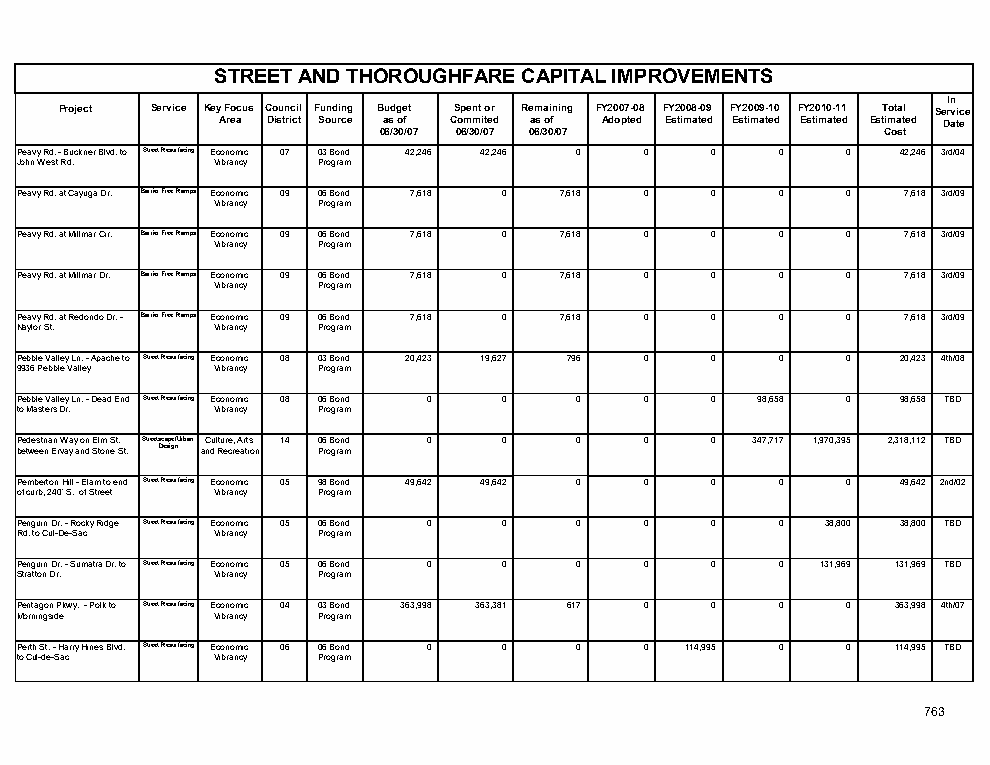

  Status   : OK

PDF: 2008.pdf  |  2748 projects  |  sampling 3  |  $K

  Project  : Sunset Ave. - Hampton Rd. to Franklin St.
  Dept     : STREET AND THOROUGHFARE  |  ID: nan
  Page     : 251  |  project_total: 30040.0 ($K)
  Years    : {'year_2008': '0.0', 'year_2009': '0.0', 'year_2010': '0.0'}


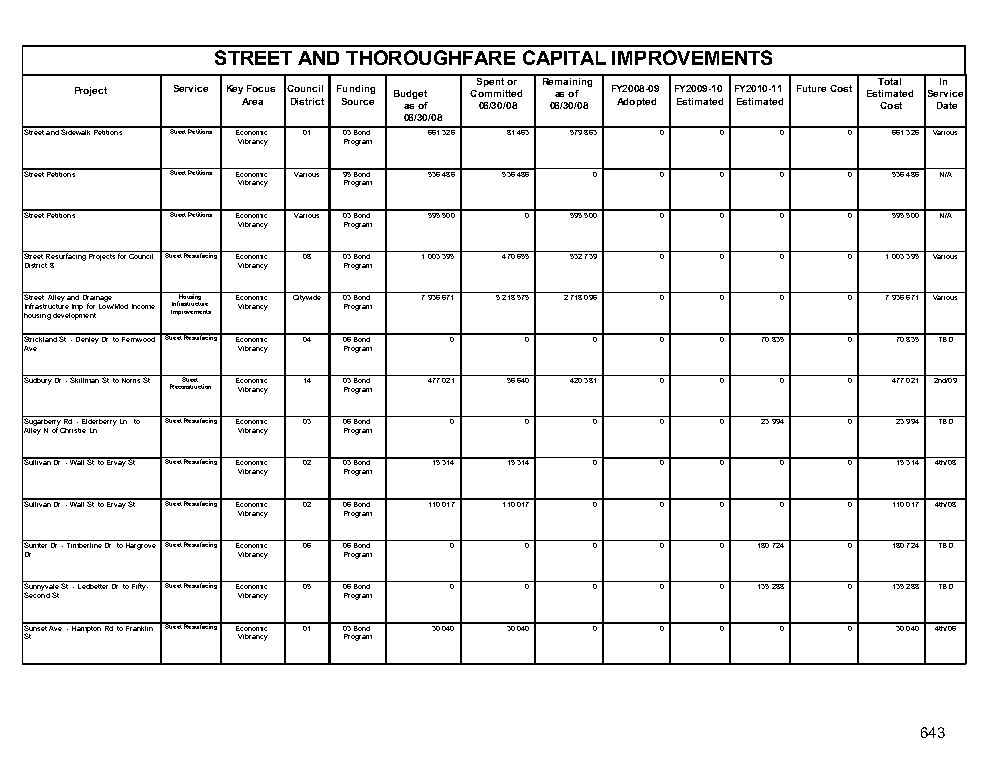

  Status   : OK

  Project  : Winchester and Berryhill - Freemont to Winchester
  Dept     : STREET AND THOROUGHFARE  |  ID: nan
  Page     : 261  |  project_total: 75825.0 ($K)
  Years    : {'year_2008': '0.0', 'year_2009': '0.0', 'year_2010': '0.0'}


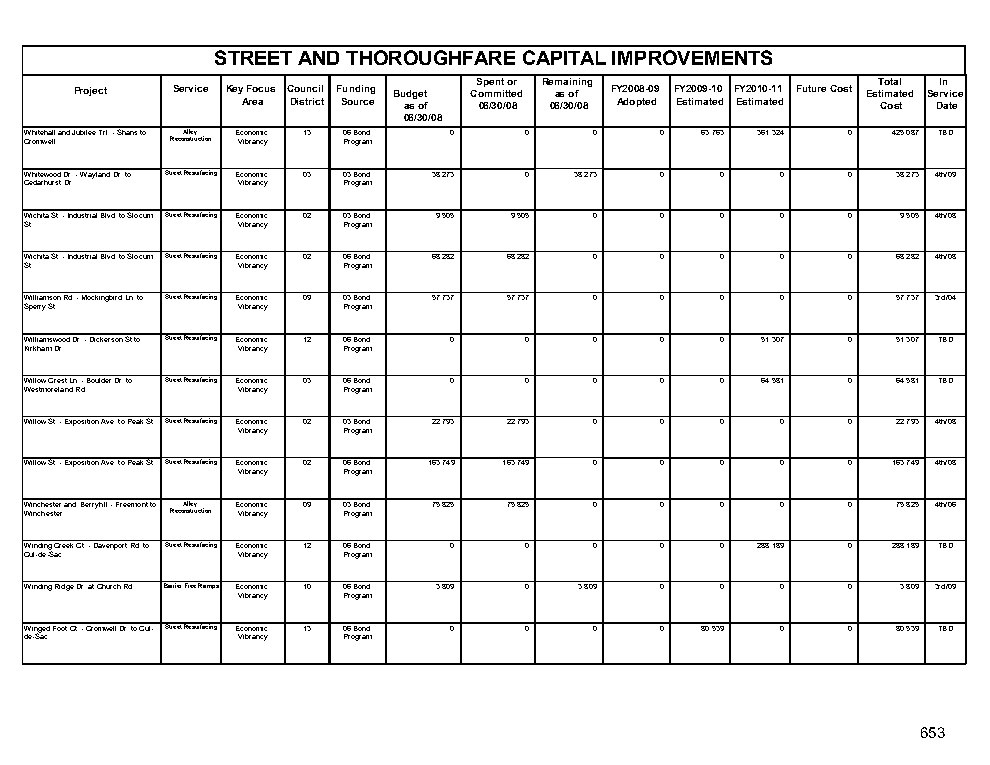

  Status   : OK

  Project  : Camp Wisdom at Mountain Creek
  Dept     : STREET AND THOROUGHFARE  |  ID: nan
  Page     : 162  |  project_total: 88770.0 ($K)
  Years    : {'year_2008': '0.0', 'year_2009': '0.0', 'year_2010': '0.0'}


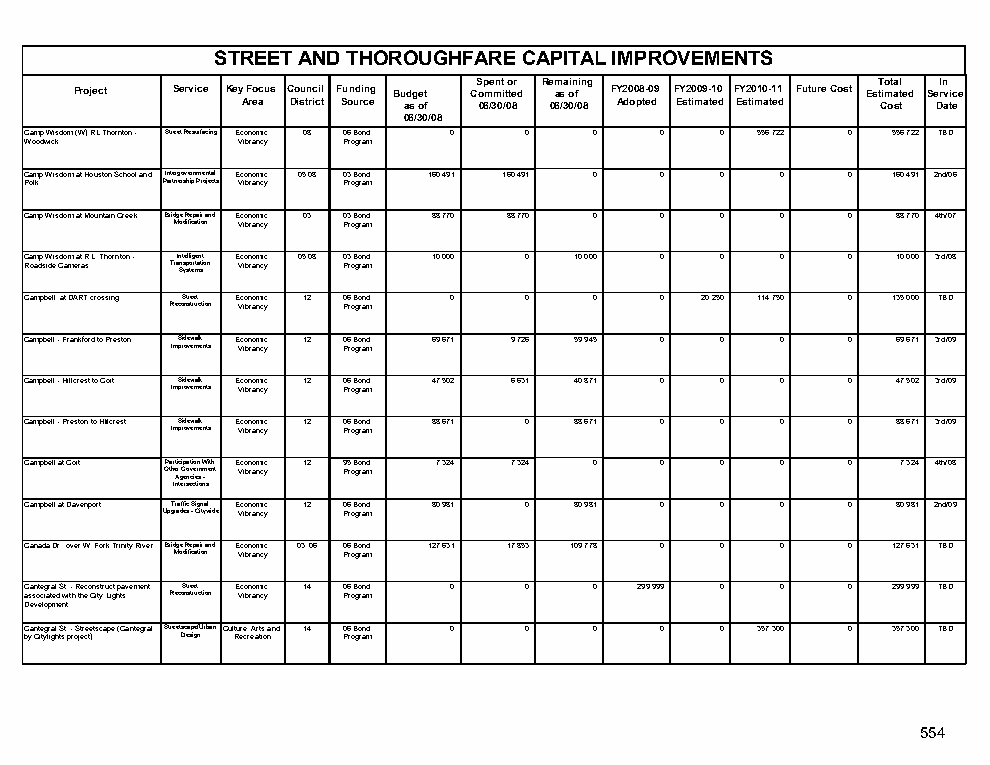

  Status   : OK

PDF: 2010.pdf  |  2222 projects  |  sampling 3  |  $K

  Project  : Fire Station #10 (Frankford at Gibbons Dr. ) - Building Expansion
  Dept     : CITY FACILITIES  |  ID: nan
  Page     : 28  |  project_total: 4317759.0 ($K)
  Years    : {'year_2010': '0.0', 'year_2011': '0.0', 'year_2012': '0.0'}


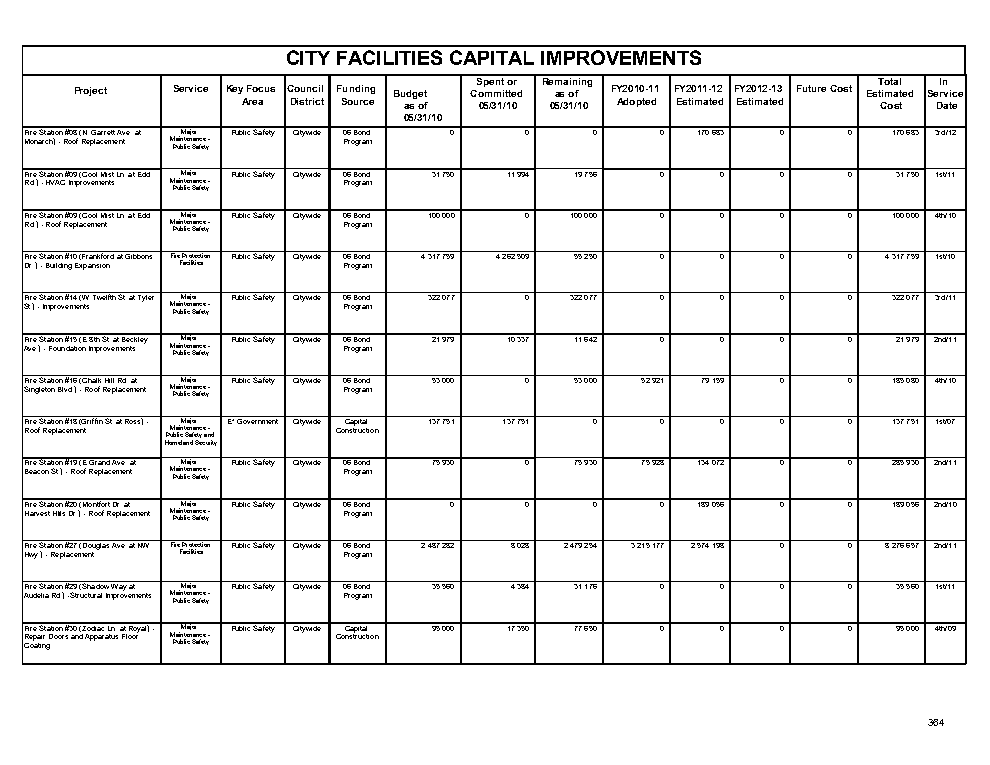

  Status   : OK

  Project  : Water Mains, Pumping and Storage Facilities
  Dept     : WATER UTILITIES  |  ID: nan
  Page     : 239  |  project_total: 284313397.0 ($K)
  Years    : {'year_2010': '49979000.0', 'year_2011': '9965000.0', 'year_2012': '1295000.0'}


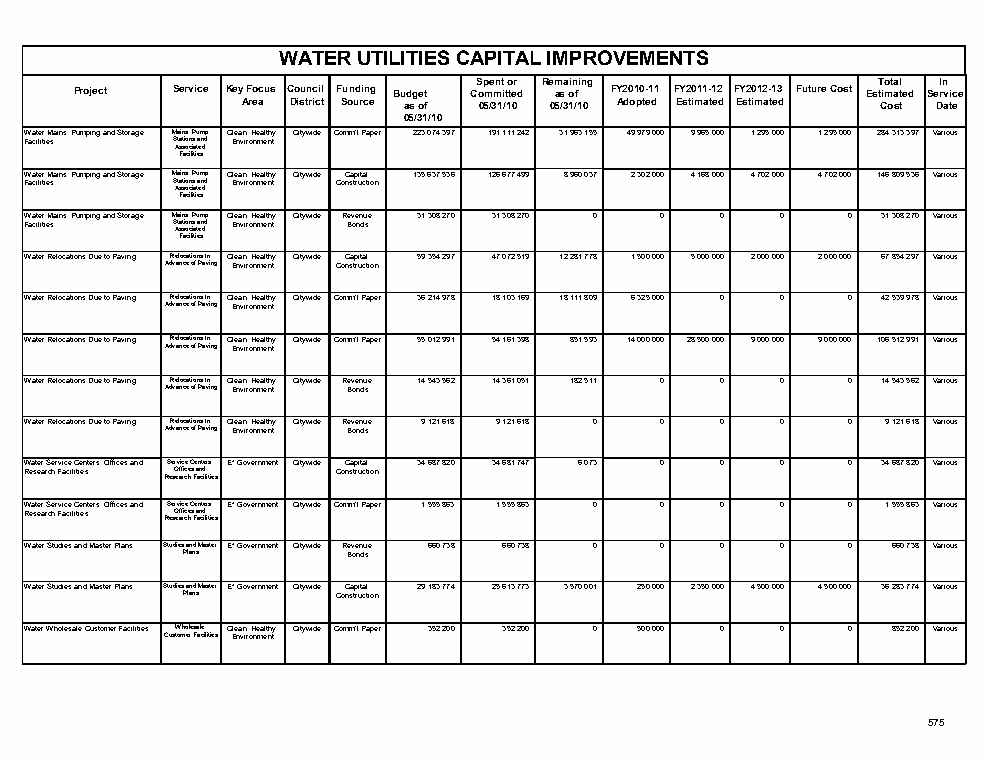

  Status   : OK

  Project  : Simpson Stuart Rd. over Fivemile Creek
  Dept     : STREET AND THOROUGHFARE  |  ID: nan
  Page     : 208  |  project_total: 159538.0 ($K)
  Years    : {'year_2010': '0.0', 'year_2011': '0.0', 'year_2012': '0.0'}


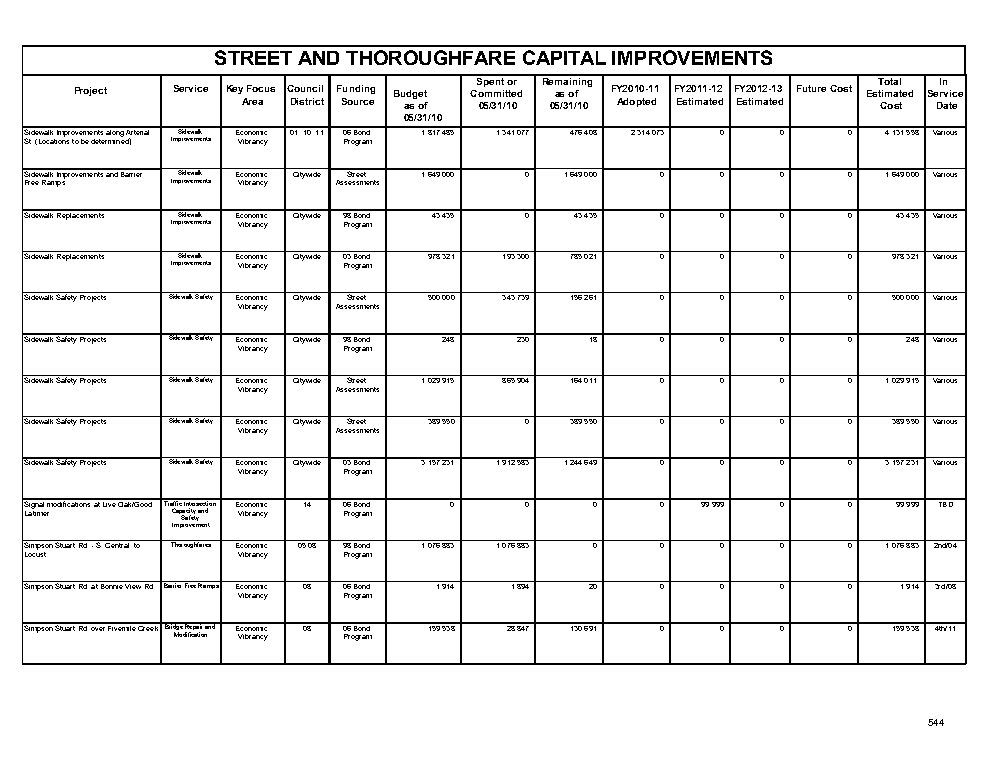

  Status   : OK

PDF: 2011.pdf  |  1793 projects  |  sampling 3  |  $K

  Project  : Kessler Pkwy. - Edgefield Ave. to Colorado Blvd.
  Dept     : STREET AND THOROUGHFARE  |  ID: nan
  Page     : 152  |  project_total: 201658.0 ($K)
  Years    : {'year_2011': '0.0', 'year_2012': '0.0', 'year_2013': '0.0'}


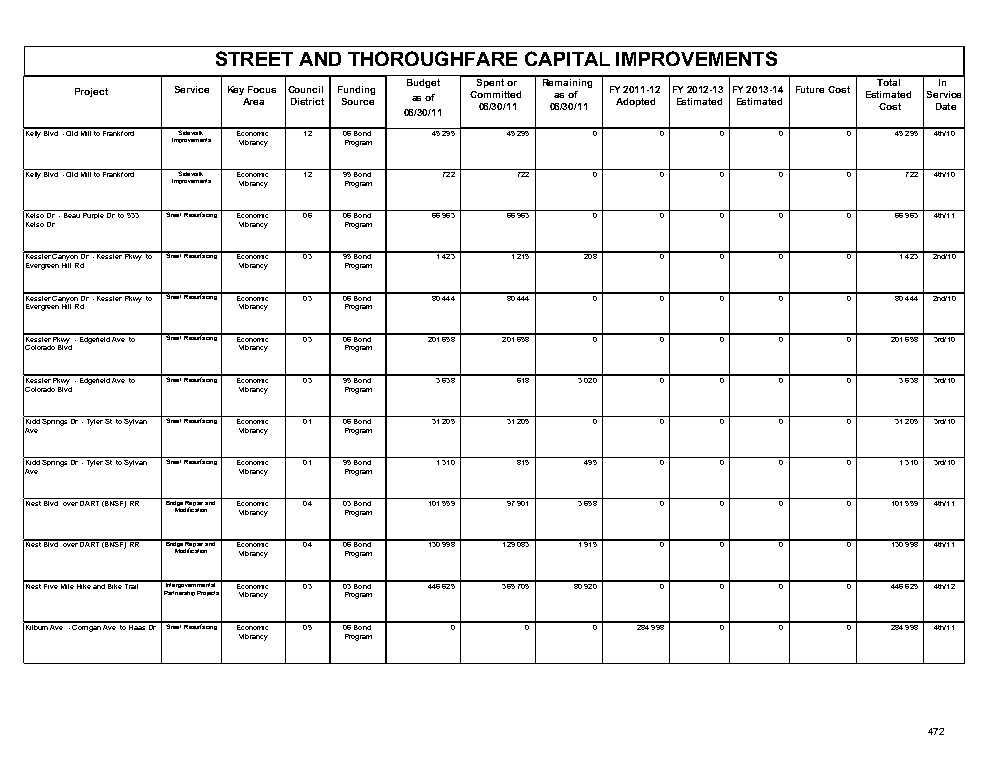

  Status   : OK

  Project  : Dallas Museum of Art - Repair Paving at Sculpture Garden
  Dept     : CULTURAL FACILITIES  |  ID: nan
  Page     : 44  |  project_total: 1715569.0 ($K)
  Years    : {'year_2011': '0.0', 'year_2012': '0.0', 'year_2013': '0.0'}


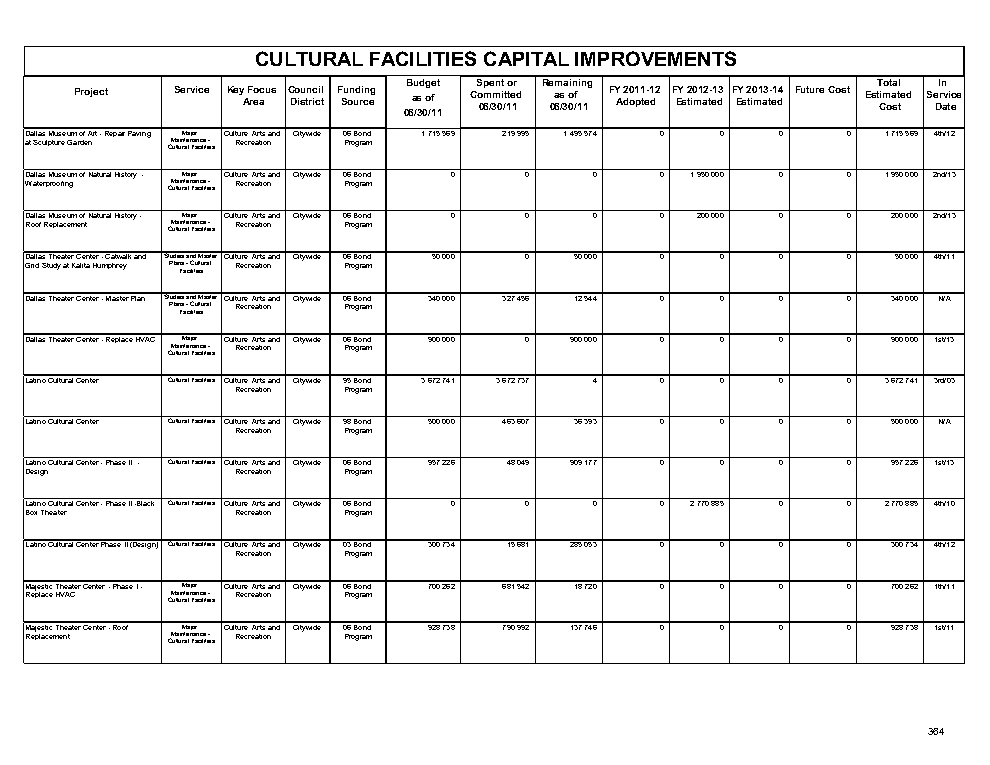

  Status   : OK

  Project  : Wastewater Relocations
  Dept     : WATER UTILITIES  |  ID: nan
  Page     : 201  |  project_total: 13065267.0 ($K)
  Years    : {'year_2011': '0.0', 'year_2012': '0.0', 'year_2013': '0.0'}


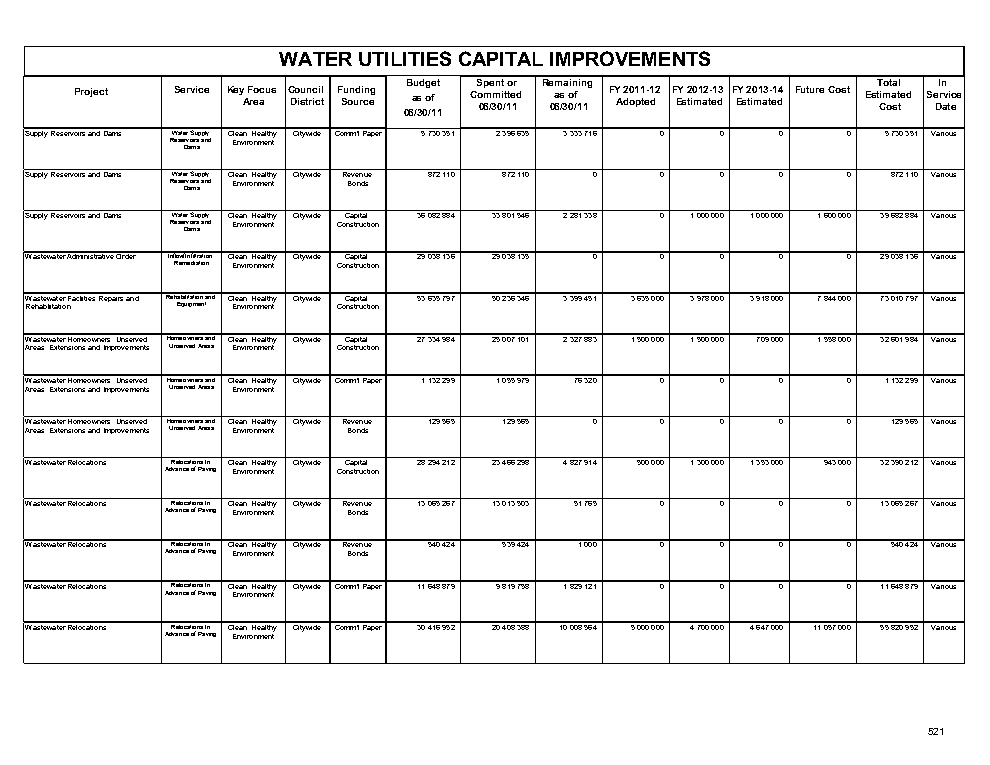

  Status   : OK

PDF: 2012.pdf  |  2031 projects  |  sampling 3  |  $K

  Project  : Park Signage
  Dept     : PARK AND RECREATION  |  ID: nan
  Page     : 104  |  project_total: 164870.0 ($K)
  Years    : {'year_2012': '0.0', 'year_2013': '0.0', 'year_2014': '0.0'}


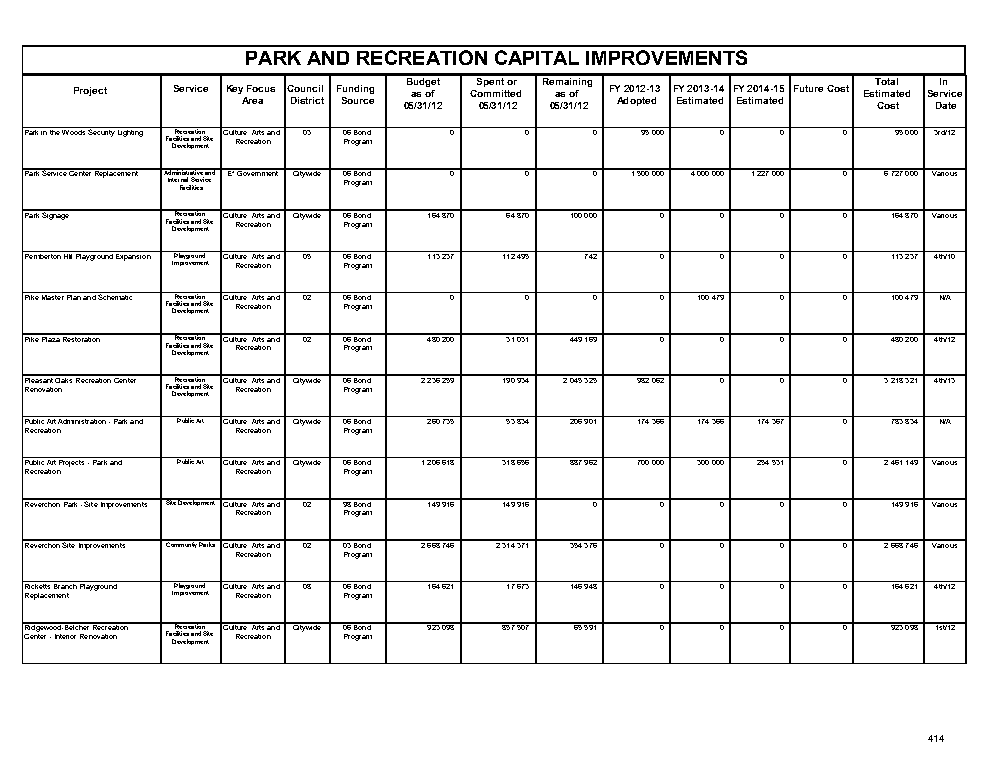

  Status   : OK

  Project  : Cockrell Hill - LaReunion to Singleton
  Dept     : STREET AND THOROUGHFARE  |  ID: nan
  Page     : 134  |  project_total: 5394907.0 ($K)
  Years    : {'year_2012': '0.0', 'year_2013': '0.0', 'year_2014': '0.0'}


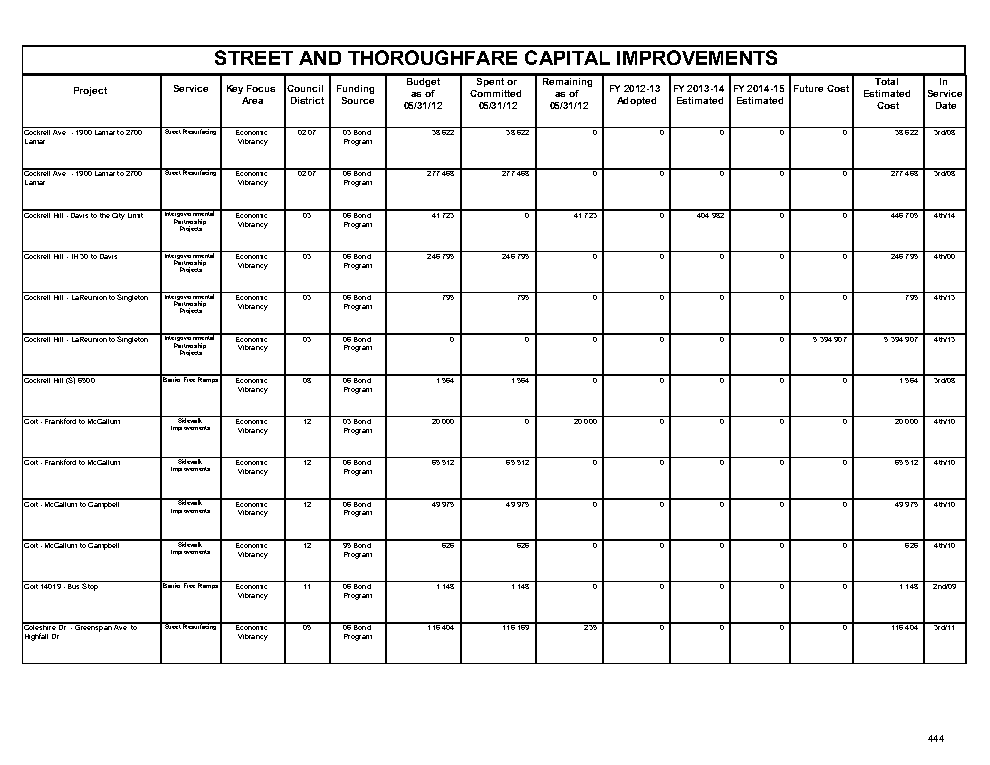

  Status   : OK

  Project  : Cotillion Site Improvements
  Dept     : PARK AND RECREATION  |  ID: nan
  Page     : 93  |  project_total: 369512.0 ($K)
  Years    : {'year_2012': '0.0', 'year_2013': '0.0', 'year_2014': '0.0'}


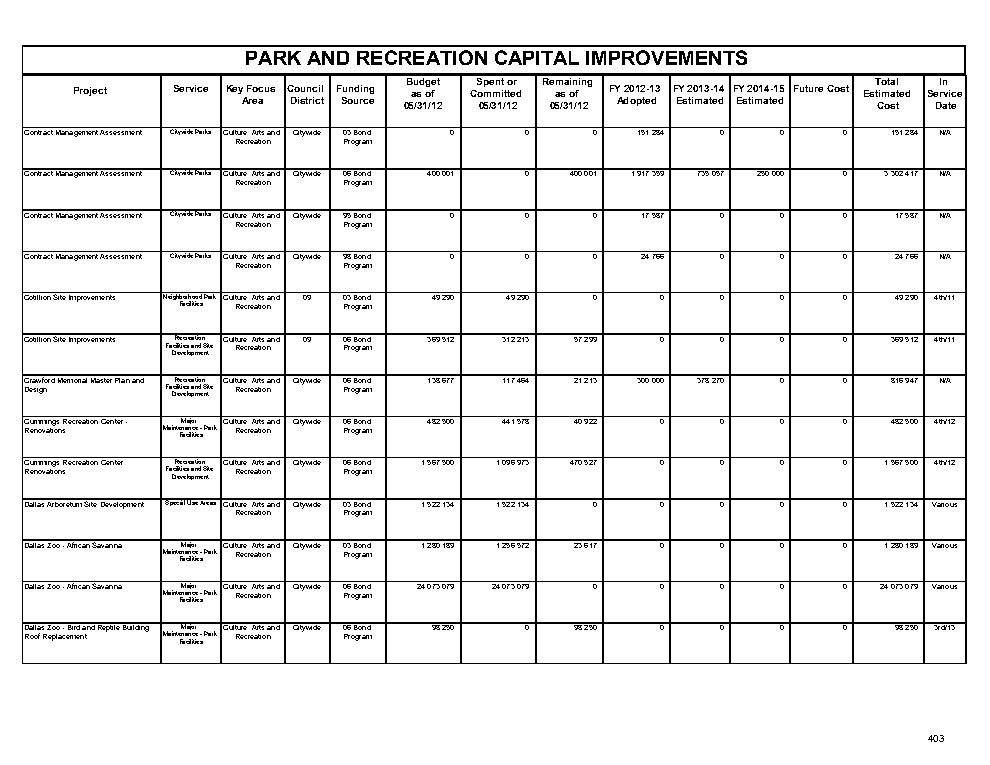

  Status   : OK

PDF: 2013.pdf  |  1767 projects  |  sampling 3  |  $K

  Project  : Stedman Dr. - Davenport Rd. to Pavement N Stedman
  Dept     : STREET AND THOROUGHFARE  |  ID: nan
  Page     : 189  |  project_total: 48824.0 ($K)
  Years    : {'year_2013': '0.0', 'year_2014': '0.0', 'year_2015': '0.0'}


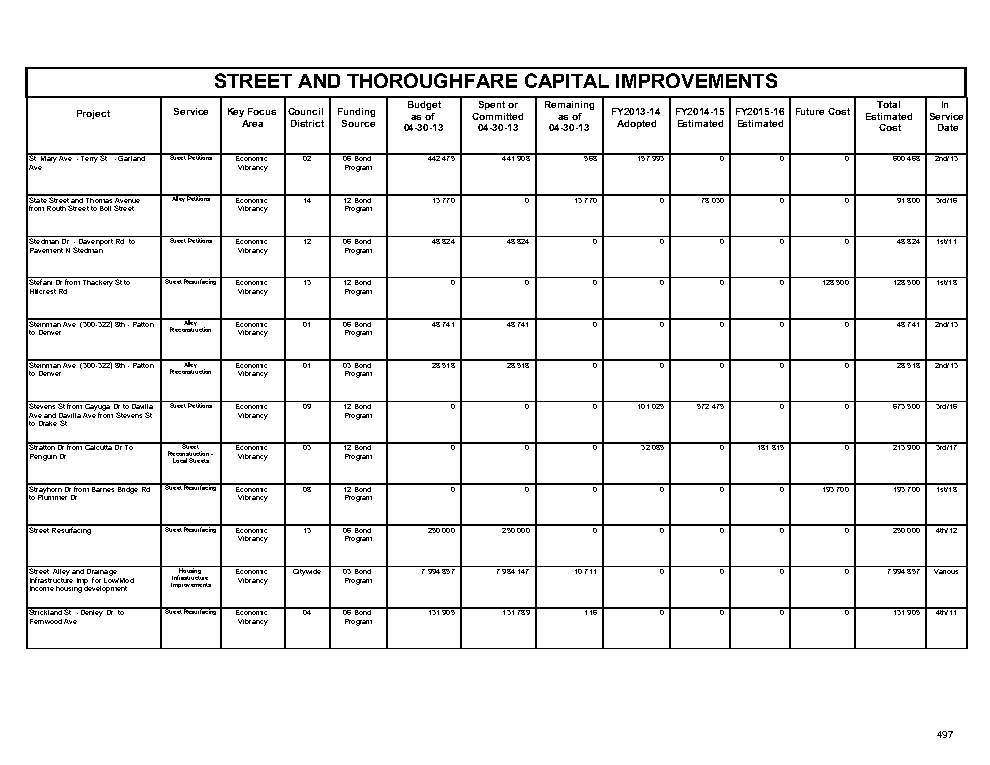

  Status   : OK

  Project  : Farmers Market Tax Increment
  Dept     : ECONOMIC DEVELOPMENT PROGRAMS AND INITIATIVES  |  ID: nan
  Page     : 55  |  project_total: 588383.0 ($K)
  Years    : {'year_2013': '0.0', 'year_2014': '0.0', 'year_2015': '0.0'}


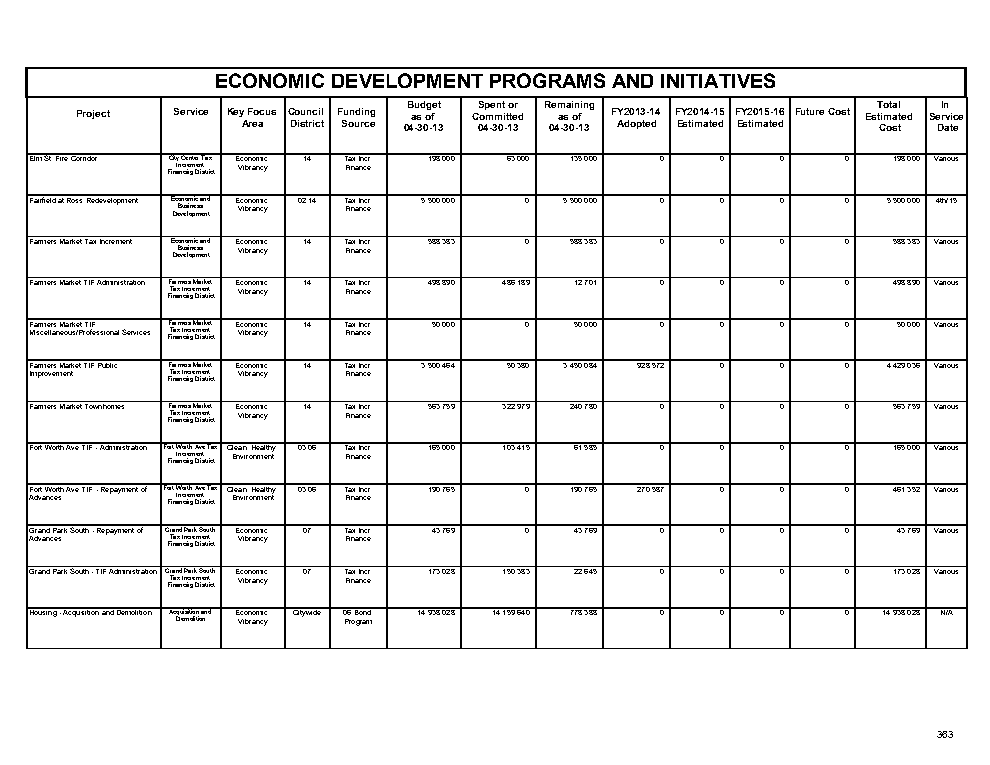

  Status   : OK

  Project  : Telephone Rd Phase I
  Dept     : STREET AND THOROUGHFARE  |  ID: nan
  Page     : 191  |  project_total: 74607.0 ($K)
  Years    : {'year_2013': '0.0', 'year_2014': '0.0', 'year_2015': '0.0'}


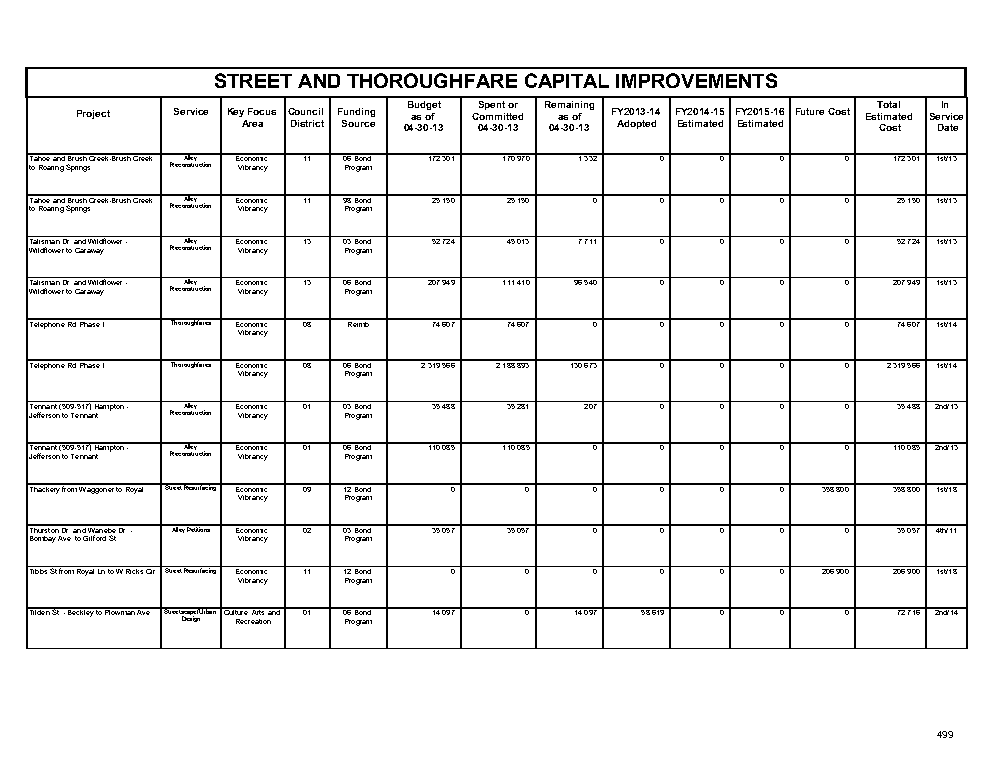

  Status   : OK

PDF: 2014.pdf  |  1467 projects  |  sampling 3  |  $K

  Project  : Public Art Projects - Streets and Transportation
  Dept     : STREET AND THOROUGHFARE  |  ID: nan
  Page     : 157  |  project_total: 42000.0 ($K)
  Years    : {'year_2014': '0.0', 'year_2015': '0.0', 'year_2016': '0.0'}


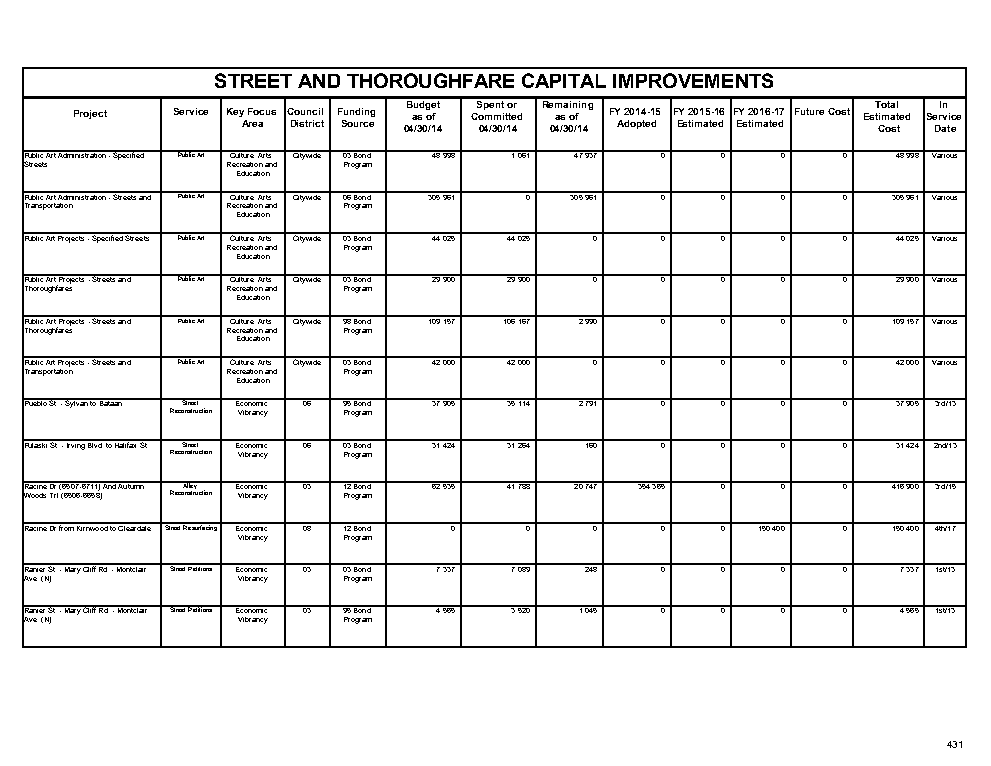

  Status   : OK

  Project  : Public Art Projects - Performing Arts Theater
  Dept     : CULTURAL FACILITIES  |  ID: nan
  Page     : 42  |  project_total: 9514.0 ($K)
  Years    : {'year_2014': '0.0', 'year_2015': '0.0', 'year_2016': '0.0'}


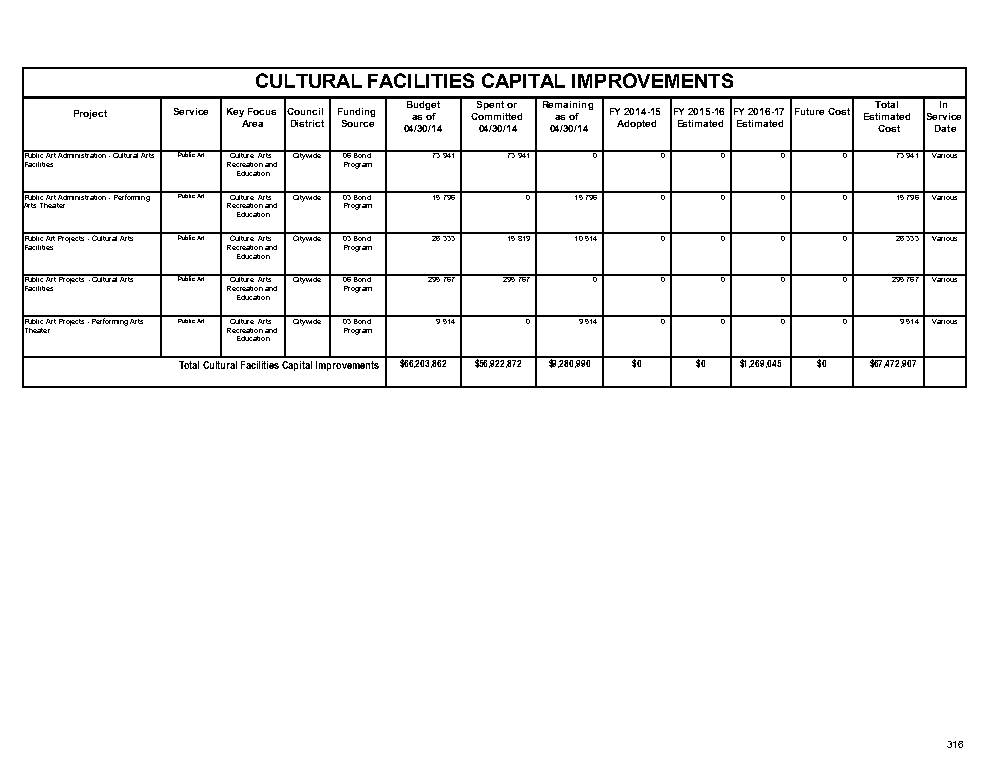

  Status   : OK

  Project  : Roundrock Rd (7707-7823) And Briaridge Rd (7708-7820)
  Dept     : STREET AND THOROUGHFARE  |  ID: nan
  Page     : 159  |  project_total: 27300.0 ($K)
  Years    : {'year_2014': '0.0', 'year_2015': '0.0', 'year_2016': '0.0'}


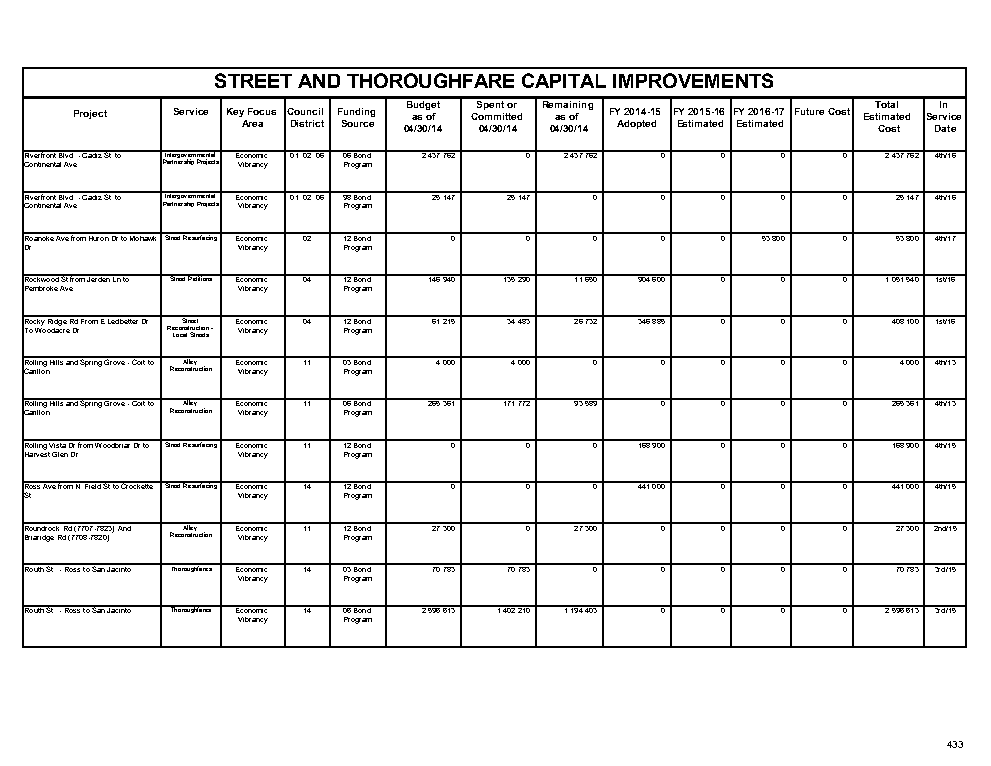

  Status   : OK

PDF: 2015.pdf  |  1284 projects  |  sampling 3  |  $K

  Project  : Supply Reservoirs and Dams
  Dept     : WATER UTILITIES  |  ID: nan
  Page     : 170  |  project_total: 1205277.0 ($K)
  Years    : {'year_2015': '0.0', 'year_2016': '0.0', 'year_2017': '0.0'}


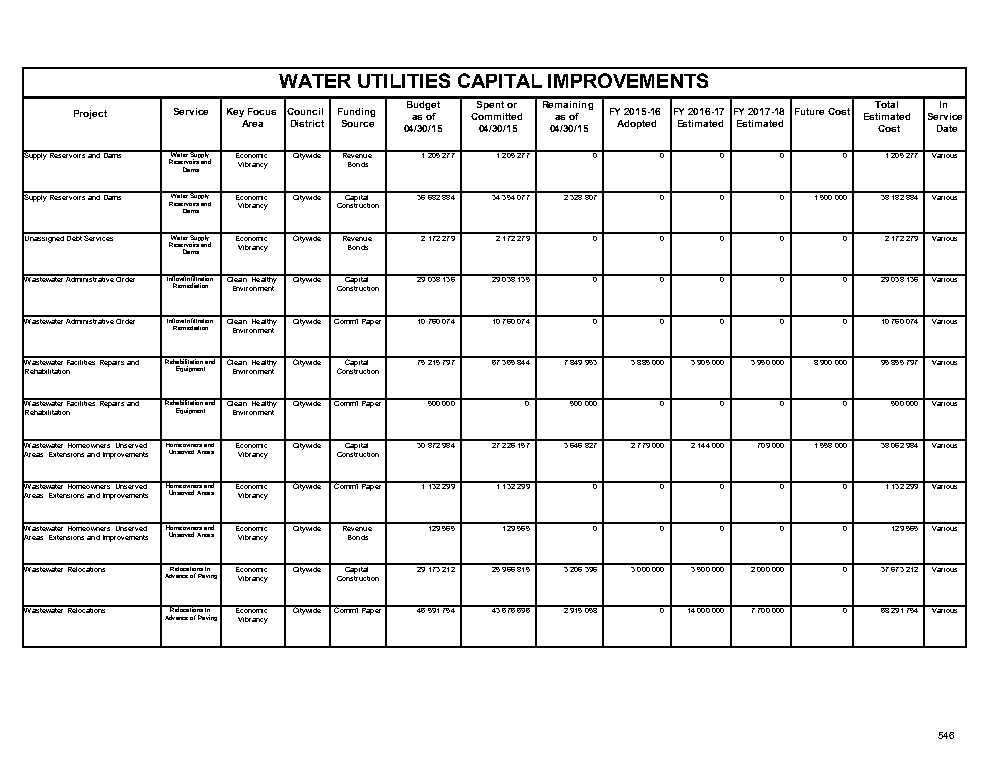

  Status   : OK

  Project  : Public Art Administration - Flood Protection and Storm Drainage
  Dept     : FLOOD PROTECTION AND STORM DRAINAGE  |  ID: nan
  Page     : 69  |  project_total: 203087.0 ($K)
  Years    : {'year_2015': '0.0', 'year_2016': '0.0', 'year_2017': '0.0'}


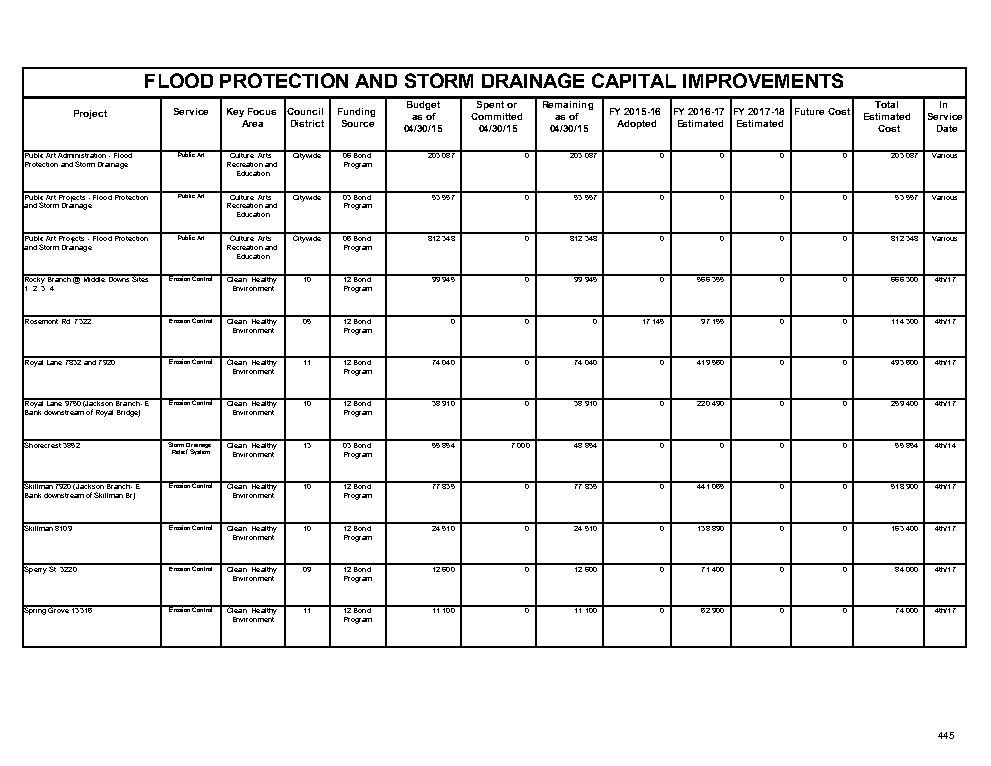

  Status   : OK

  Project  : Polk St. (S) - Ferndale Ave. to Clarendon Ave.
  Dept     : STREET AND THOROUGHFARE  |  ID: nan
  Page     : 140  |  project_total: 350445.0 ($K)
  Years    : {'year_2015': '0.0', 'year_2016': '0.0', 'year_2017': '0.0'}


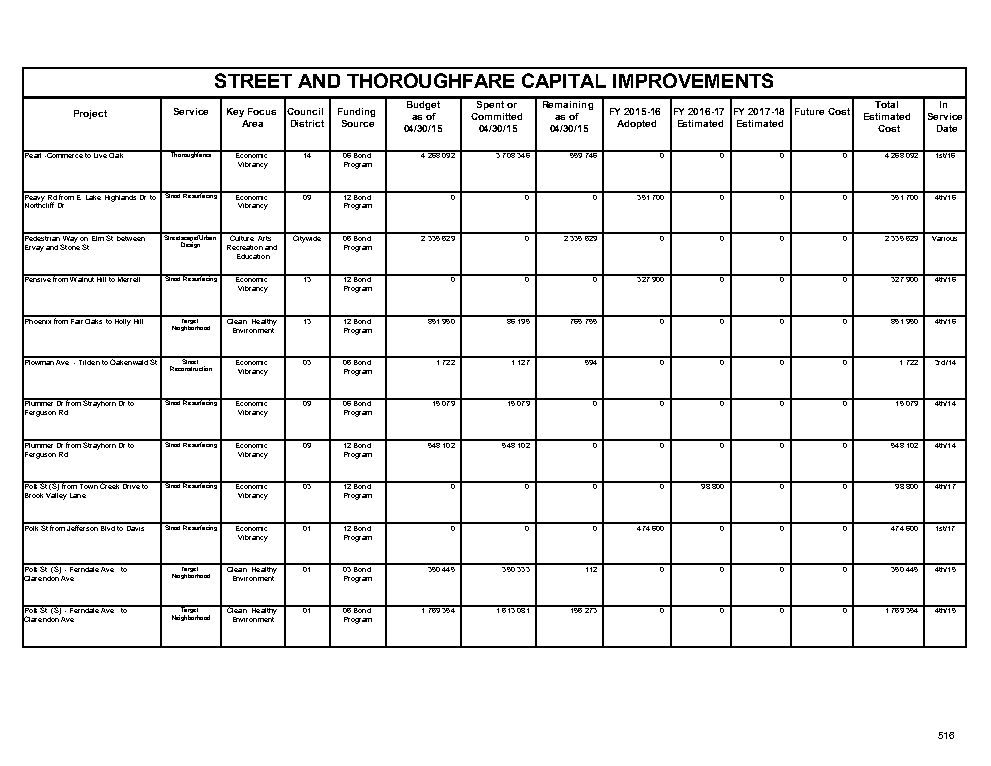

  Status   : OK

PDF: 2016.pdf  |  1147 projects  |  sampling 3  |  $K

  Project  : Martin Weiss Park Site 3- Pedestrian Bridge
  Dept     : FLOOD PROTECTION AND STORM DRAINAGE  |  ID: nan
  Page     : 68  |  project_total: 5235.0 ($K)
  Years    : {'year_2016': '0.0', 'year_2017': '0.0', 'year_2018': '0.0'}


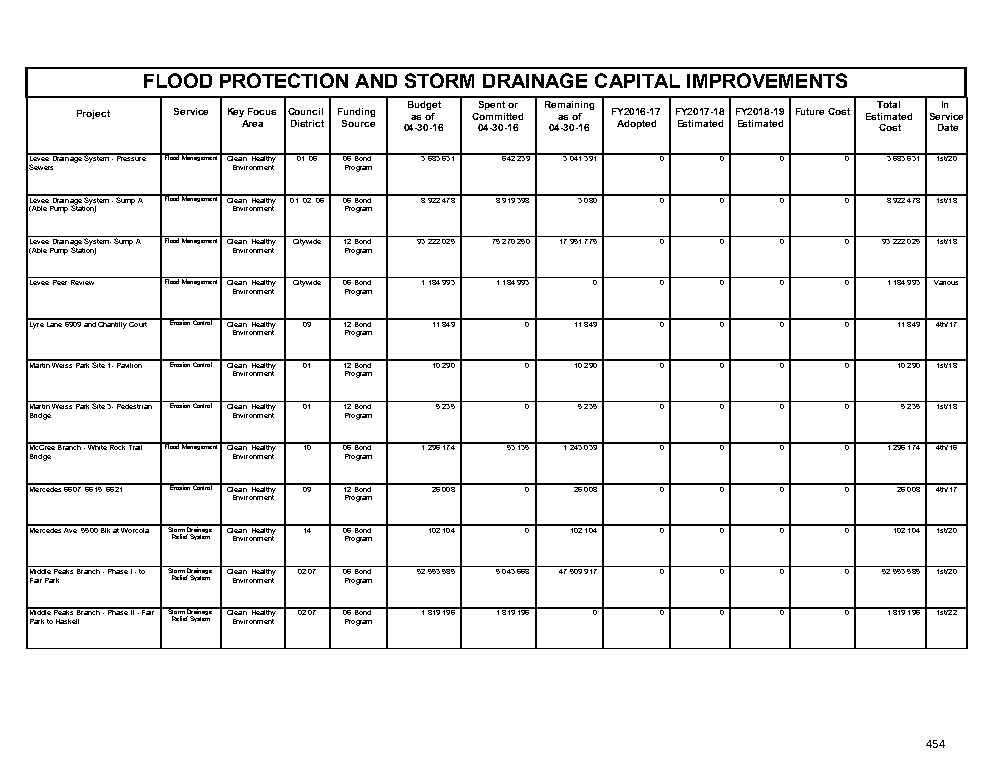

  Status   : OK

  Project  : Supply Reservoirs and Dams
  Dept     : WATER UTILITIES  |  ID: nan
  Page     : 161  |  project_total: 6447660.0 ($K)
  Years    : {'year_2016': '0.0', 'year_2017': '0.0', 'year_2018': '0.0'}


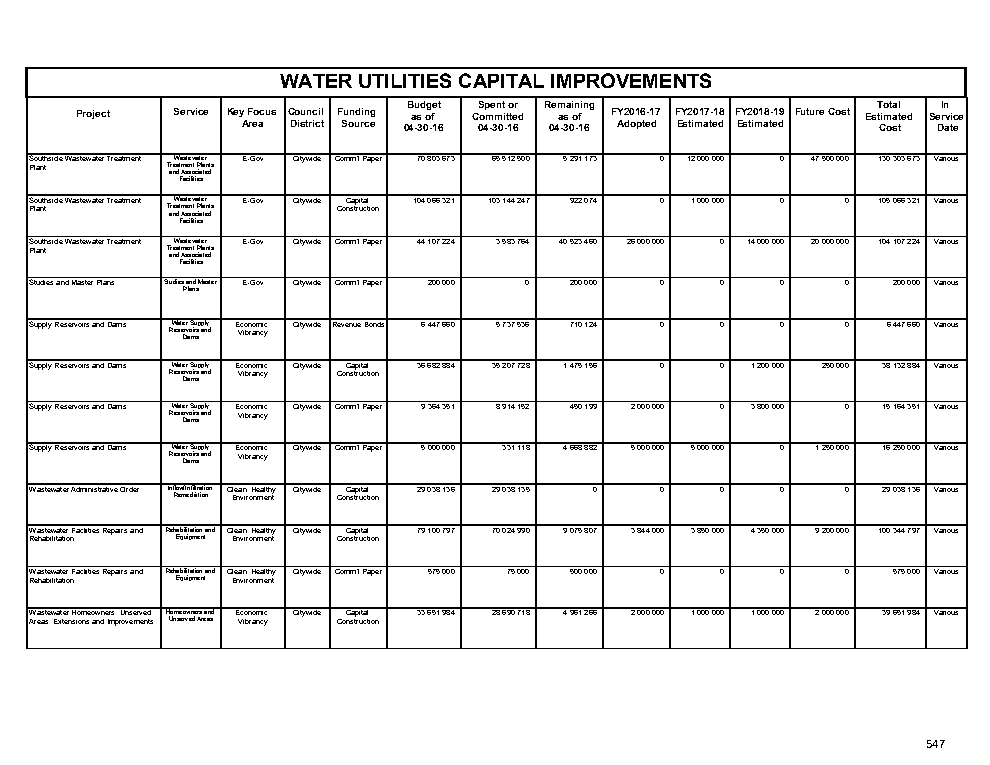

  Status   : OK

  Project  : Meadow Gate Ln (2703-2763) And Meadow Isle Ln (2704-2764)
  Dept     : STREET AND THOROUGHFARE  |  ID: nan
  Page     : 131  |  project_total: 196885.0 ($K)
  Years    : {'year_2016': '0.0', 'year_2017': '0.0', 'year_2018': '0.0'}


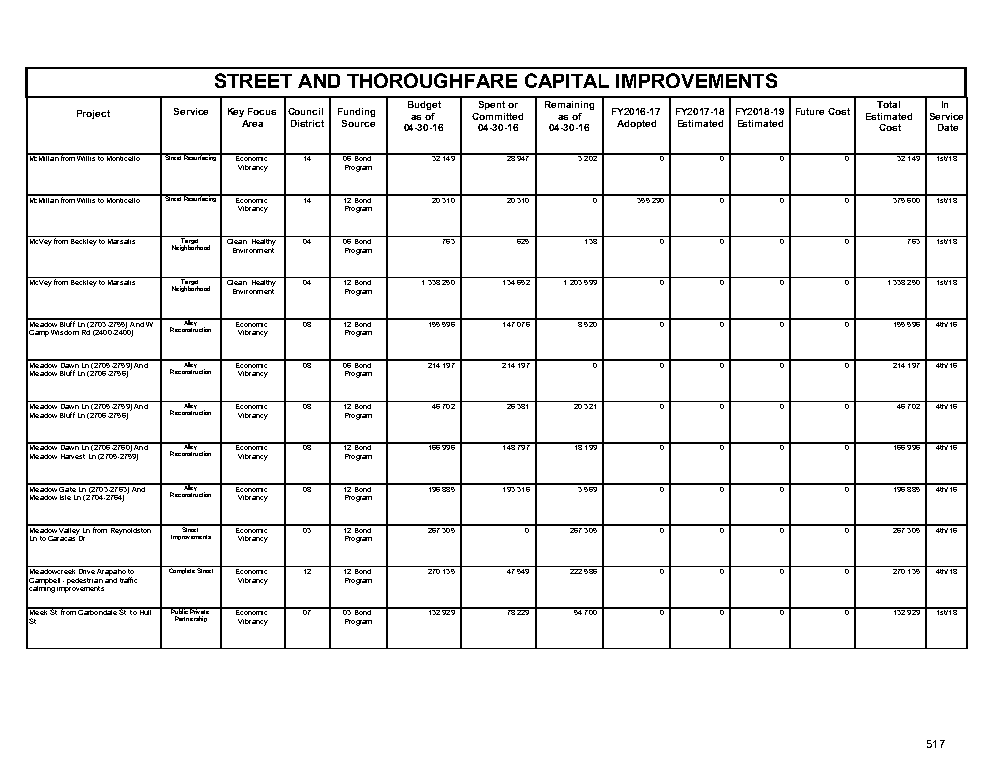

  Status   : OK

PDF: 2017.pdf  |  742 projects  |  sampling 3  |  $K

  Project  : 24000 Blk Hooper
  Dept     : ECONOMIC DEVELOPMENT PROGRAMS AND INITIATIVES  |  ID: nan
  Page     : 55  |  project_total: 0.0 ($K)
  Years    : {'year_2017': '0.0', 'year_2018': '0.0', 'year_2019': '0.0'}


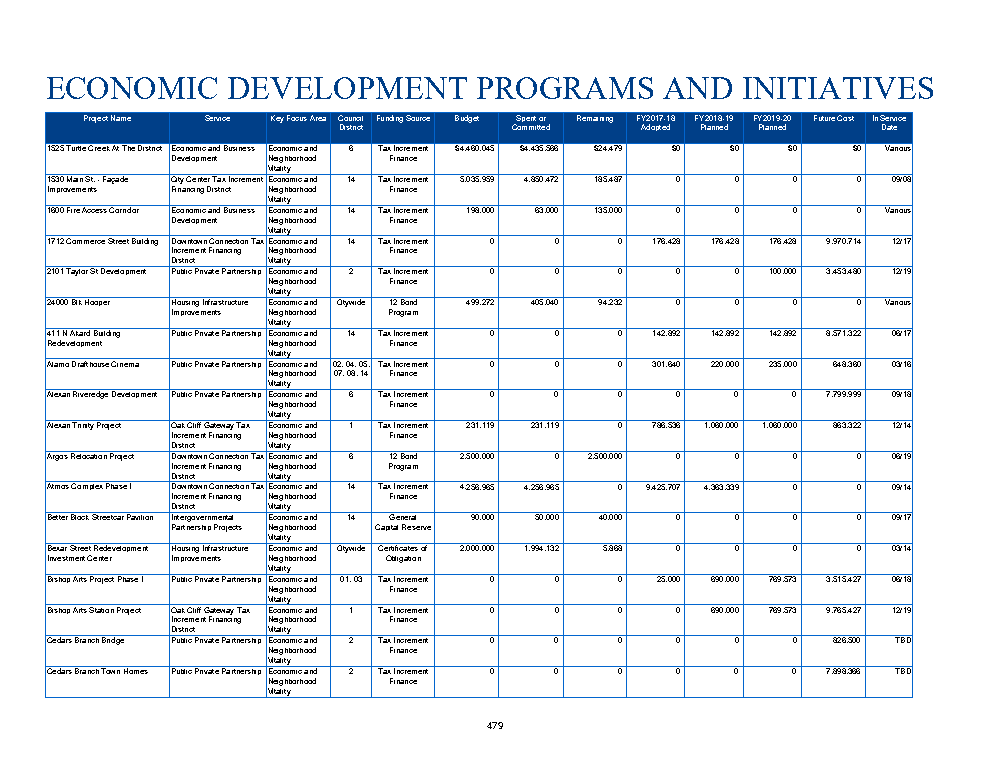

  Status   : OK

  Project  : North Parking Garage Project
  Dept     : ECONOMIC DEVELOPMENT PROGRAMS AND INITIATIVES  |  ID: nan
  Page     : 59  |  project_total: 0.0 ($K)
  Years    : {'year_2017': '1834565.0', 'year_2018': '1019887.0', 'year_2019': '1993035.0'}


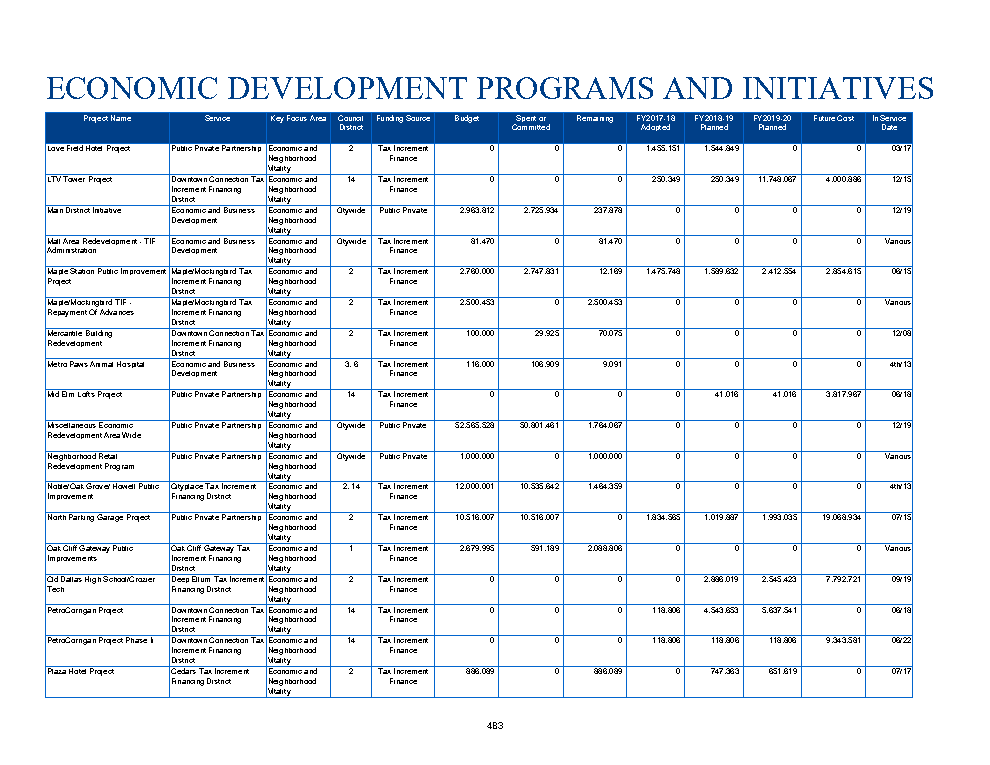

  Status   : OK

  Project  : Spring Valley 8444
  Dept     : FLOOD PROTECTION AND STORM DRAINAGE  |  ID: nan
  Page     : 76  |  project_total: 0.0 ($K)
  Years    : {'year_2017': '0.0', 'year_2018': '0.0', 'year_2019': '0.0'}


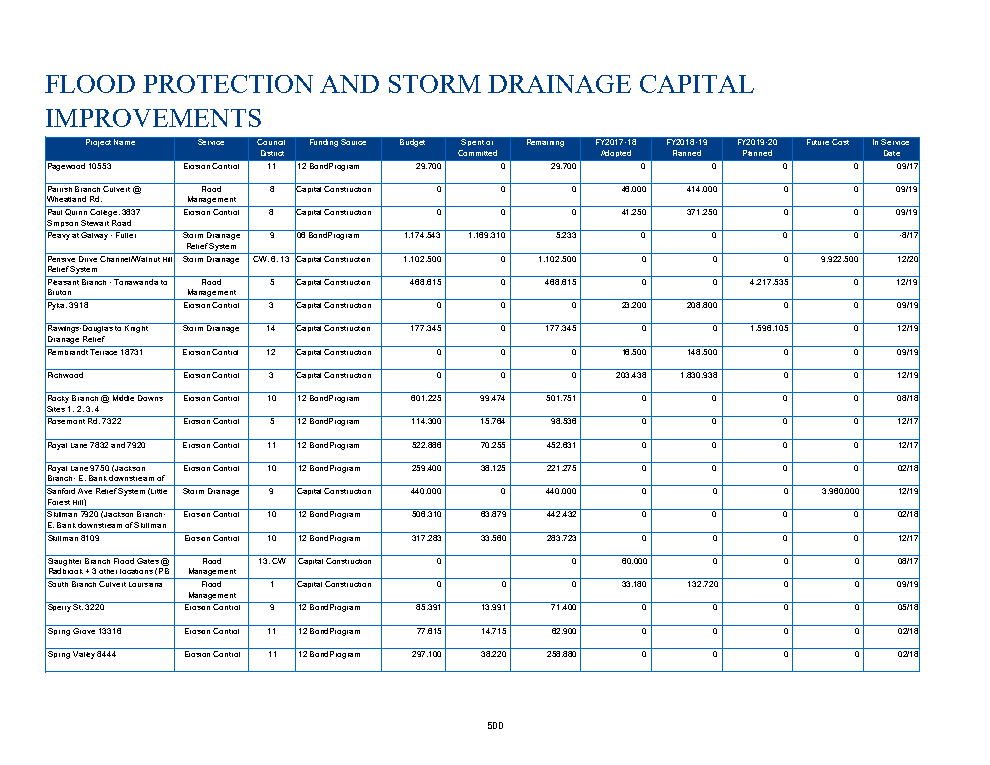

  Status   : OK

PDF: 2018.pdf  |  321 projects  |  sampling 3  |  $K

  Project  : Squaw Valley 17628
  Dept     : MANAGEMENT  |  ID: S754
  Page     : 203  |  project_total: 80140.0 ($K)
  Years    : {'year_2018': '0.0', 'year_2019': '0.0', 'year_2020': '0.0', 'year_2021': '0.0', 'year_2022': '0.0'}


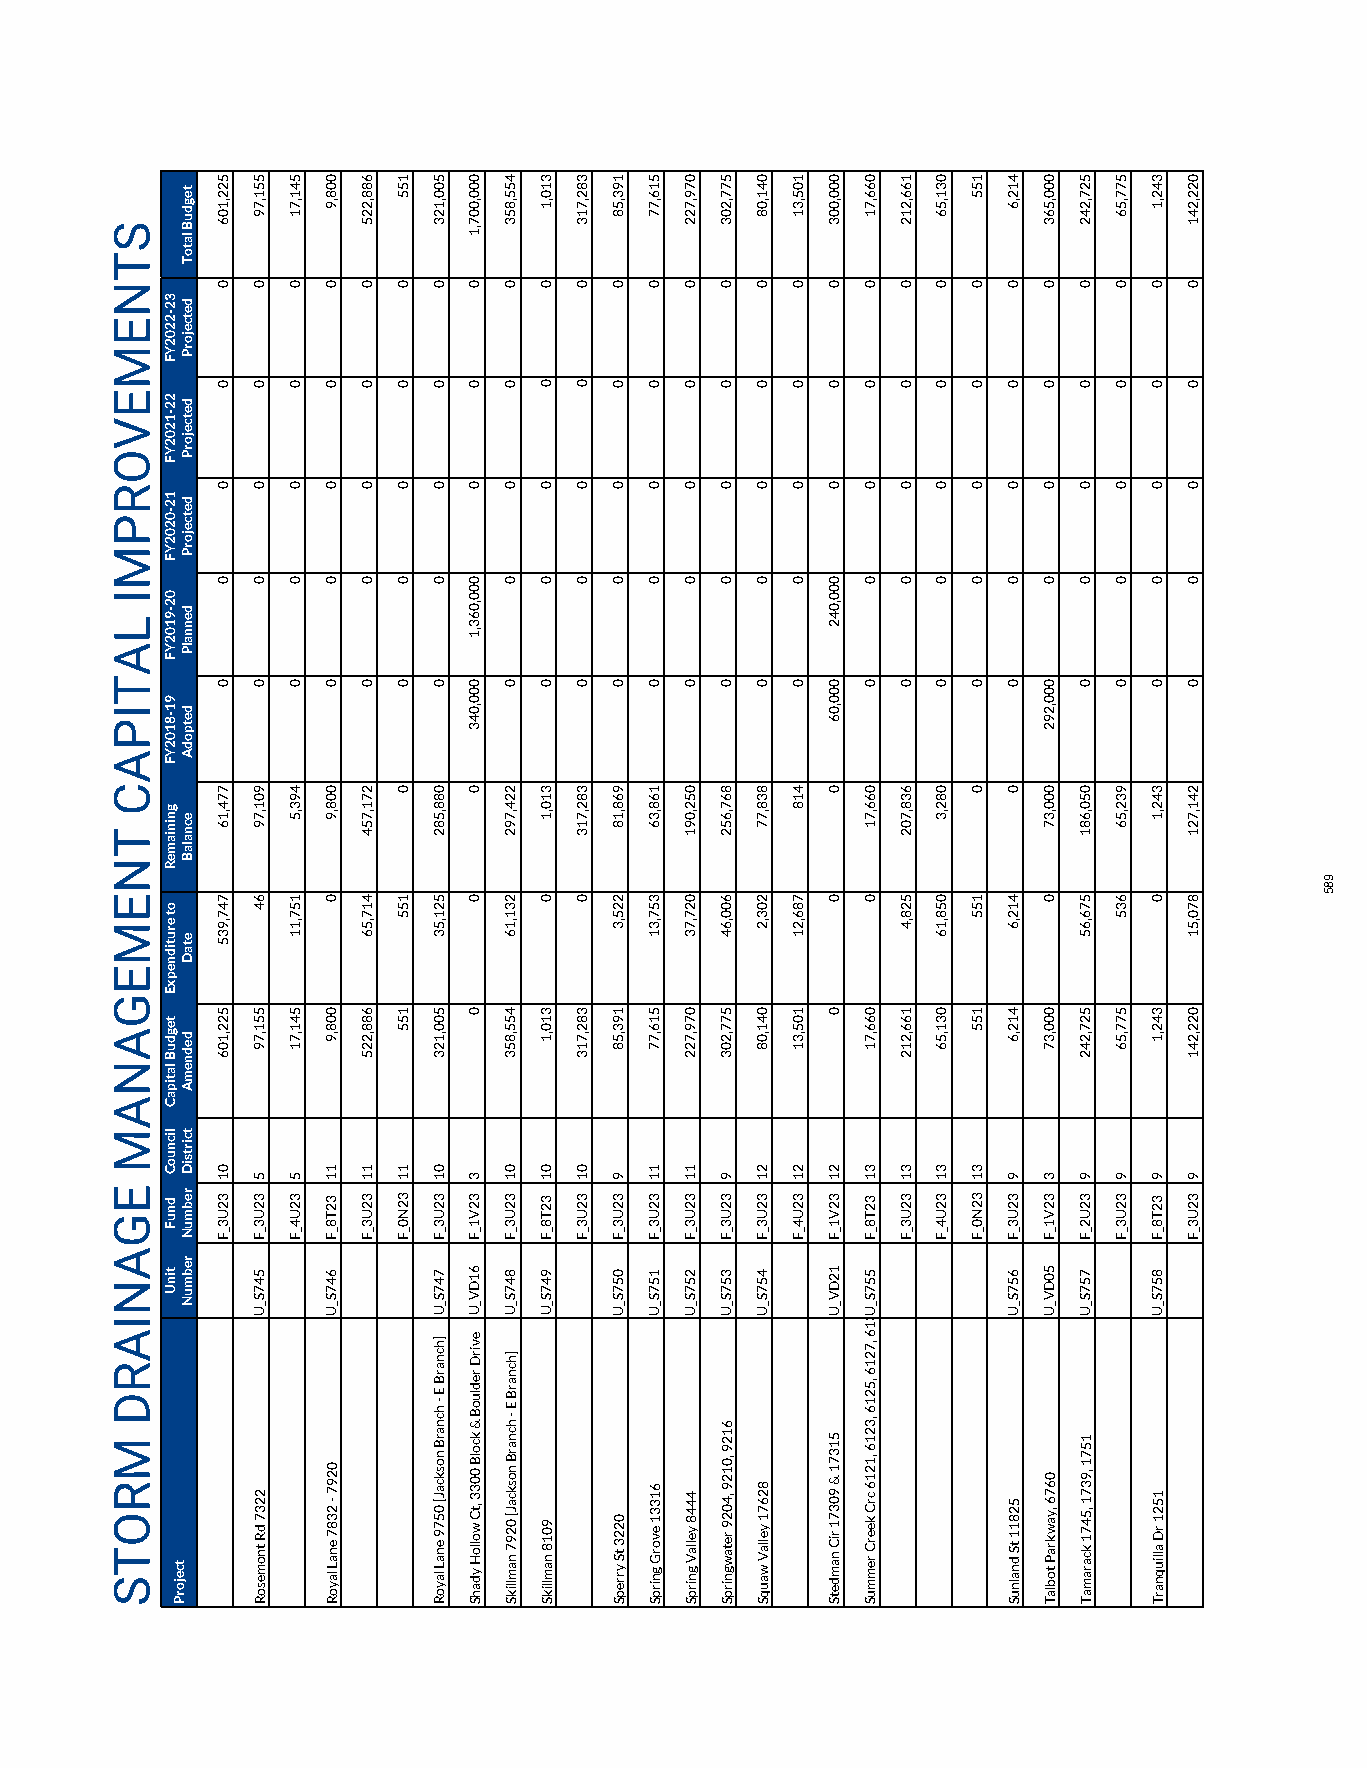

  Status   : OK

  Project  : Glendale Park Site 4 - N Of Footbridge
  Dept     : MANAGEMENT  |  ID: S726
  Page     : 201  |  project_total: 34300.0 ($K)
  Years    : {'year_2018': '0.0', 'year_2019': '0.0', 'year_2020': '0.0', 'year_2021': '0.0', 'year_2022': '0.0'}


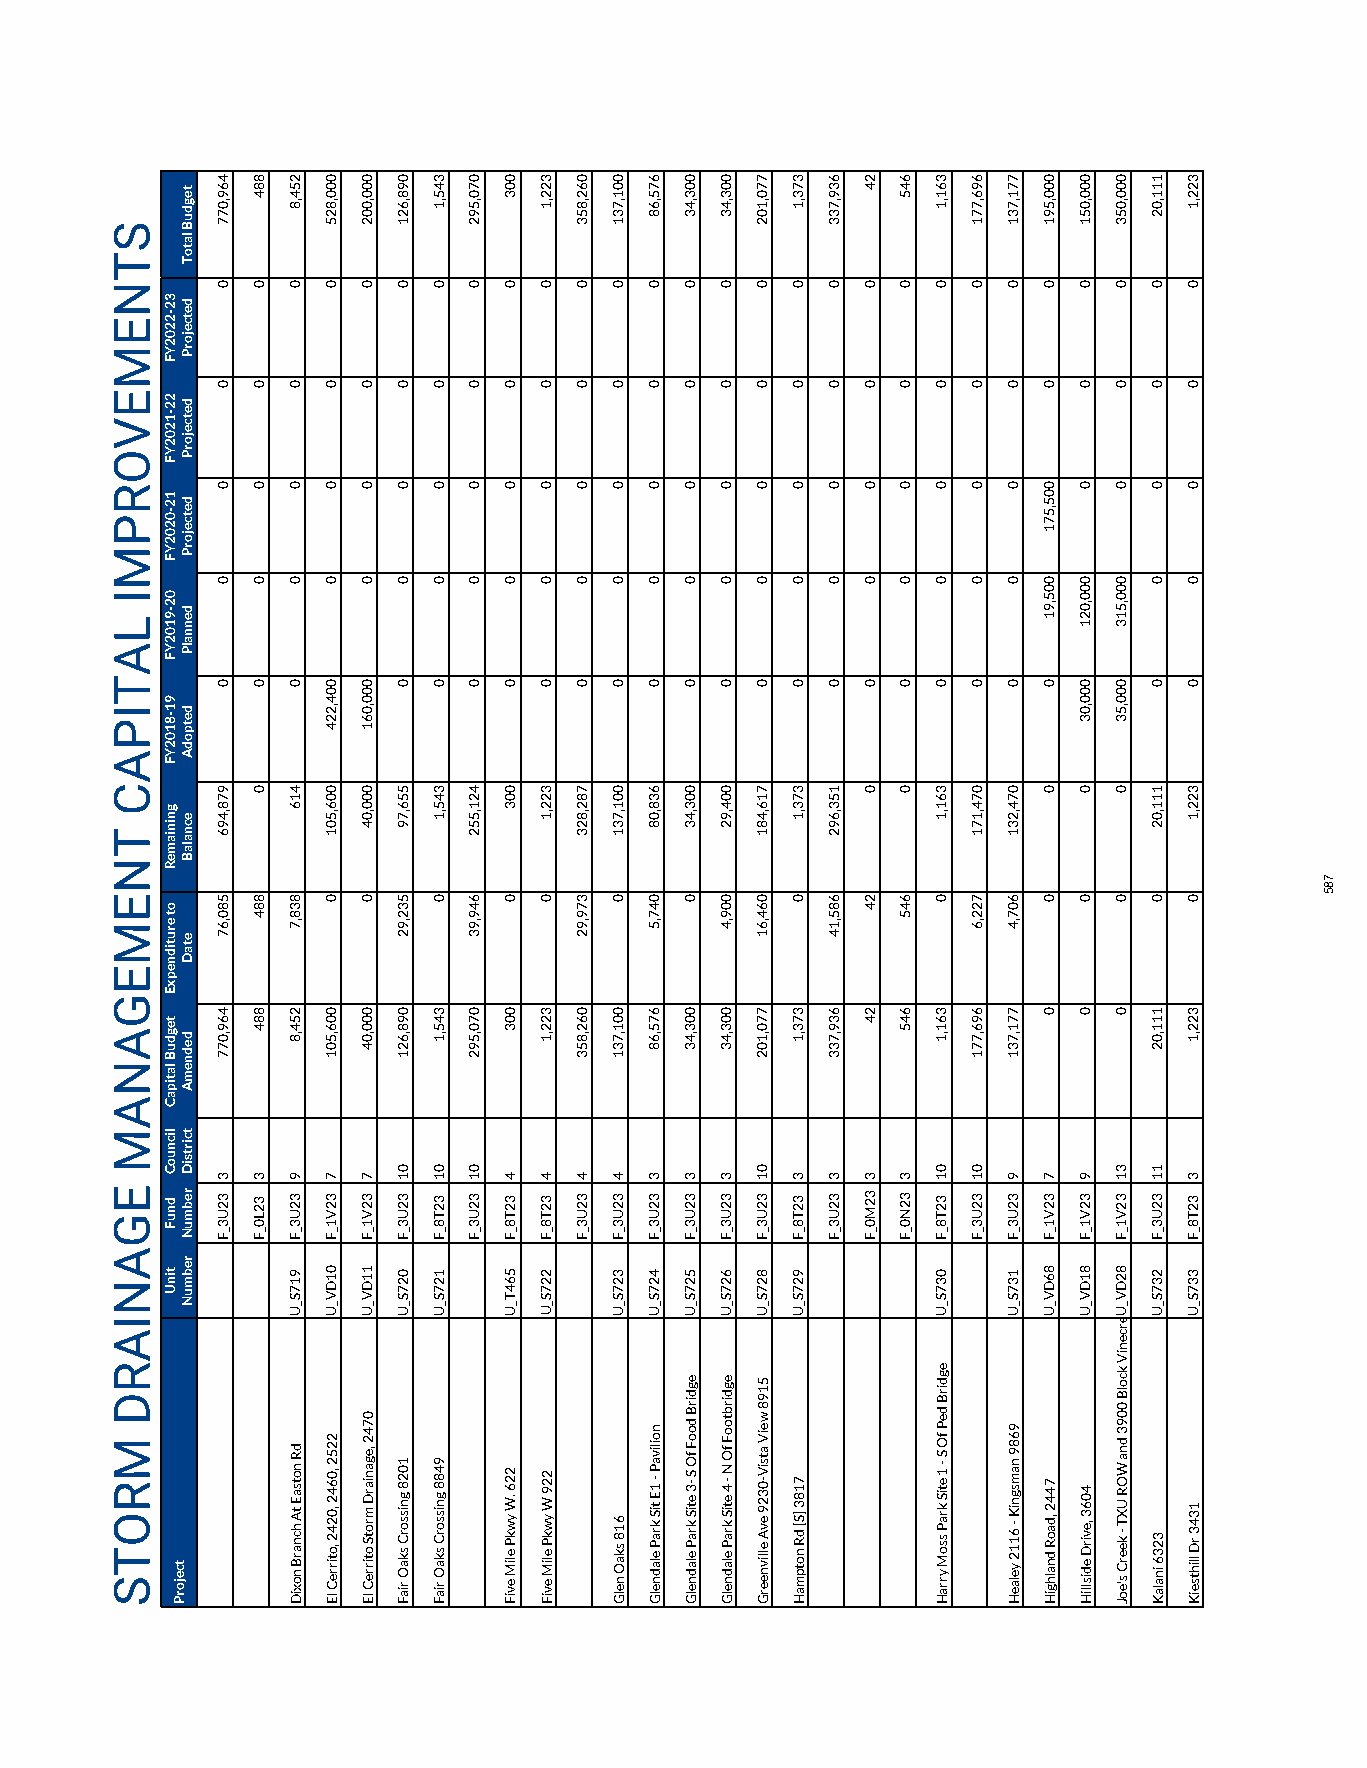

  Status   : OK

  Project  : Reserve Bond Projects
  Dept     : MANAGEMENT  |  ID: RV23
  Page     : 205  |  project_total: 1066.0 ($K)
  Years    : {'year_2018': '0.0', 'year_2019': '0.0', 'year_2020': '0.0', 'year_2021': '0.0', 'year_2022': '0.0'}


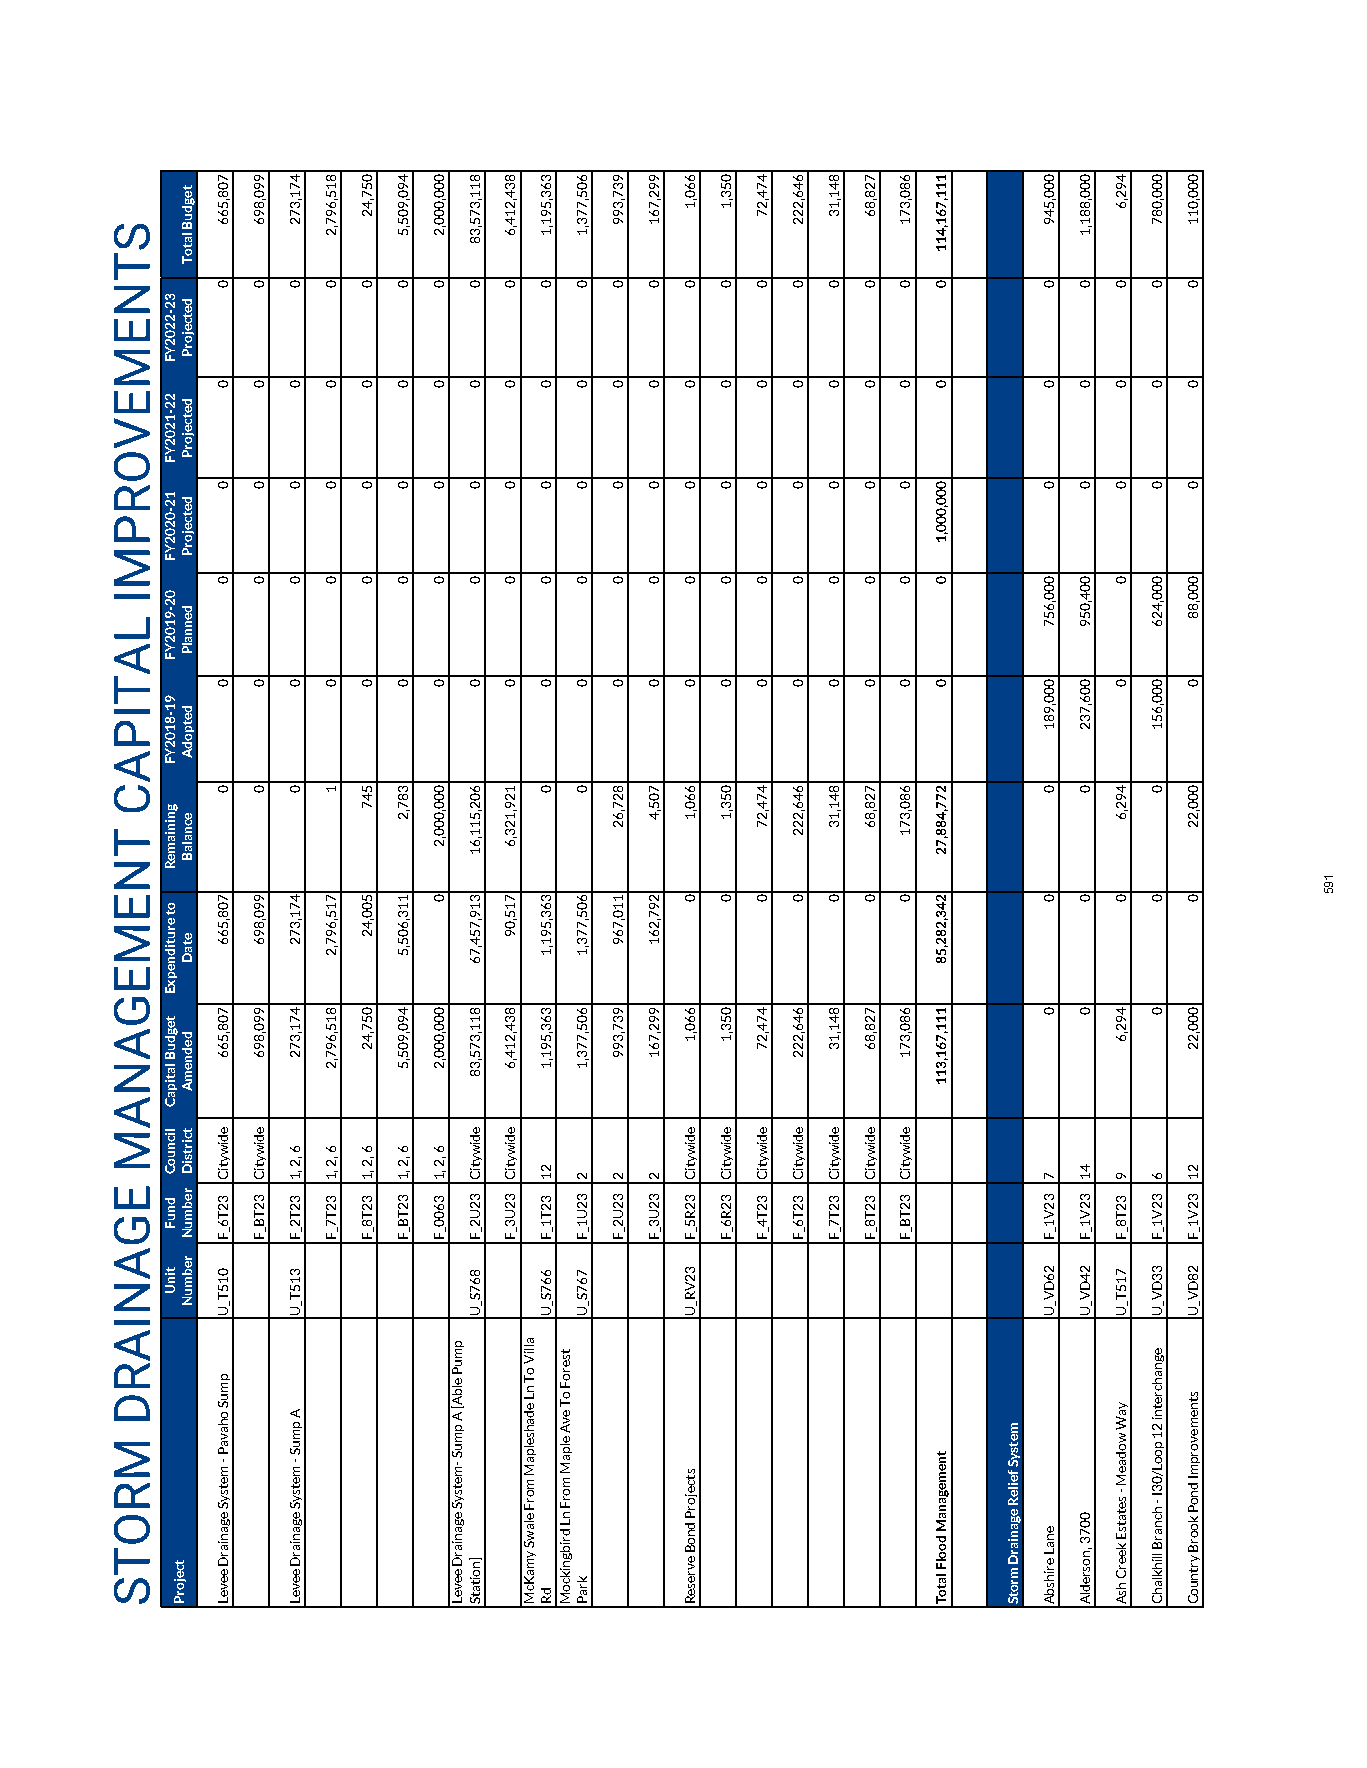

  Status   : OK

PDF: 2019.pdf  |  2043 projects  |  sampling 3  |  $K

  Project  : Frankford Rd from Hillcrest Rd to Coit Rd
  Dept     : PARK & RECREATION  |  ID: V933
  Page     : 123  |  project_total: 1604875.0 ($K)
  Years    : {'year_2019': '0.0', 'year_2020': '1604875.0', 'year_2021': '0.0'}


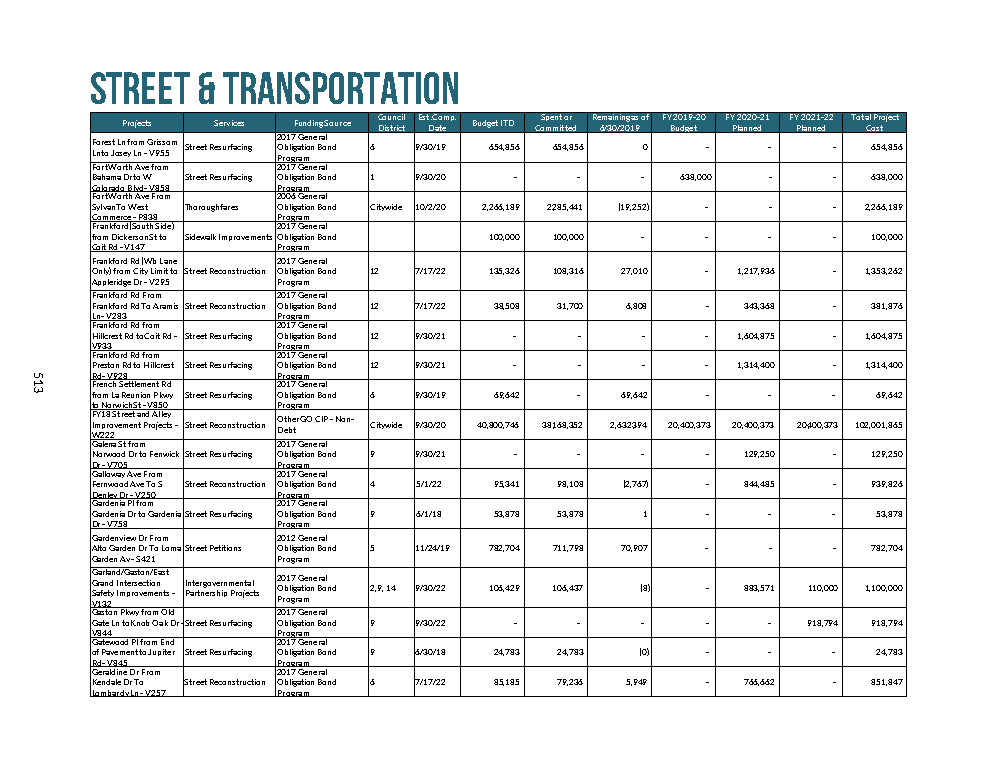

  Status   : OK

  Project  : Avenue F from E 11th St Sanderson Ave
  Dept     : PARK & RECREATION  |  ID: V323
  Page     : 105  |  project_total: 100.0 ($K)
  Years    : {'year_2019': '0.0', 'year_2020': '0.0', 'year_2021': '0.0'}


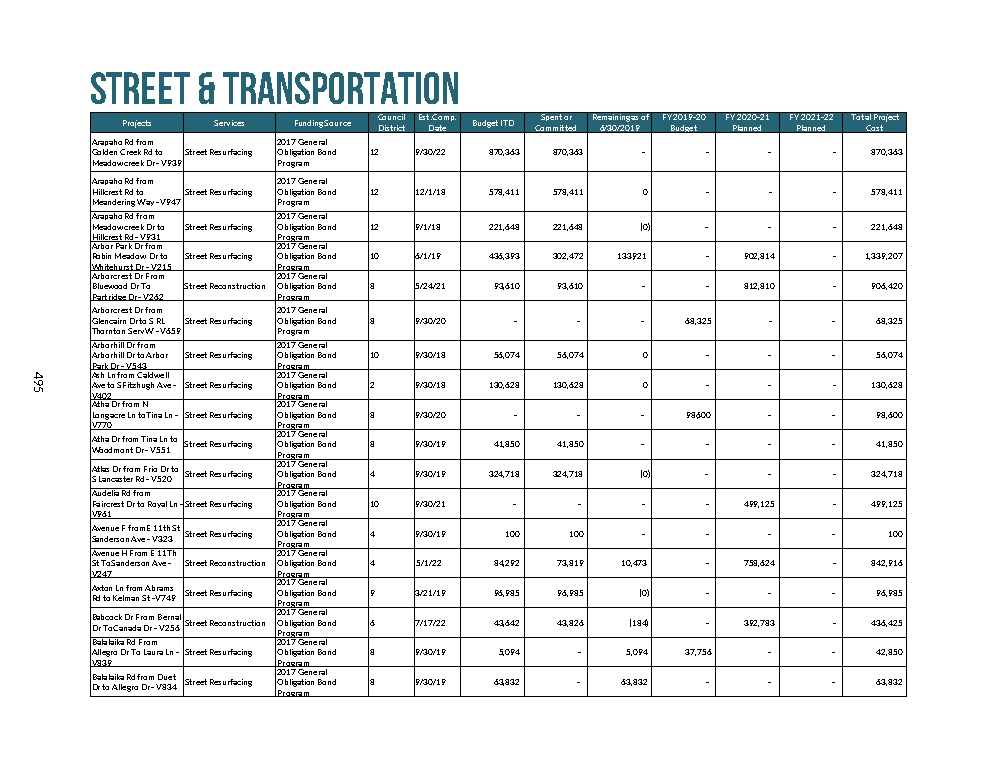

  Status   : OK

  Project  : Brookview Dr Gloster Rd
  Dept     : PARK & RECREATION  |  ID: S223
  Page     : 109  |  project_total: 312048.0 ($K)
  Years    : {'year_2019': '0.0', 'year_2020': '0.0', 'year_2021': '0.0'}


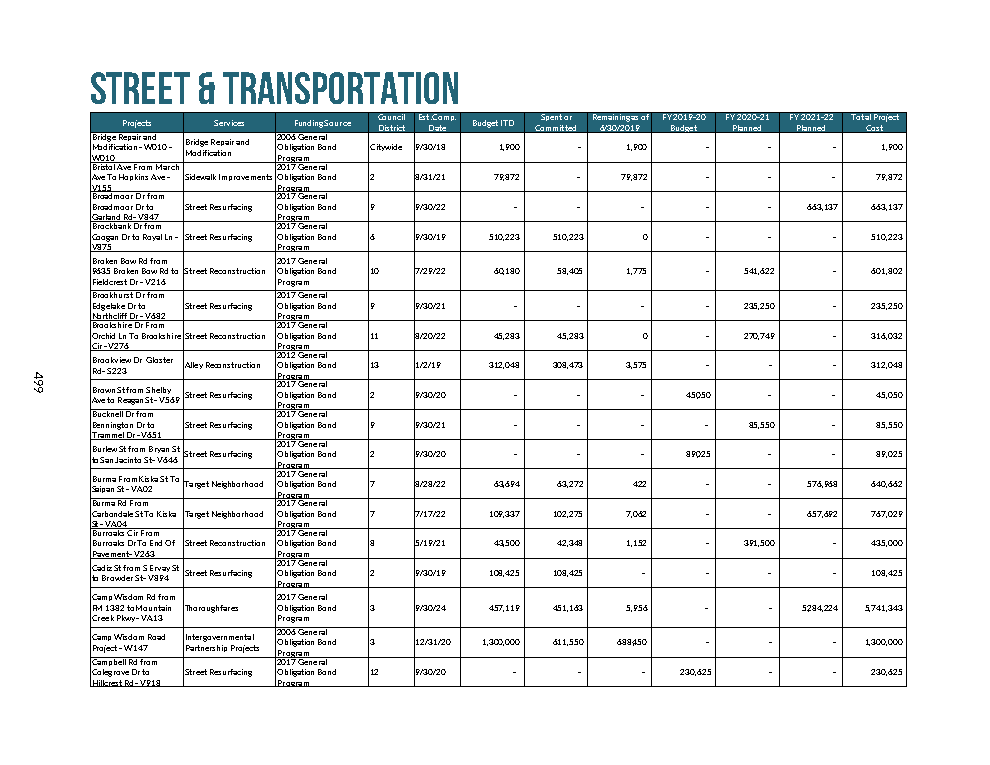

  Status   : OK

PDF: 2020.pdf  |  895 projects  |  sampling 3  |  $K

  Project  : Whittier Ave from San Benito Way to San Leandro Dr
  Dept     : SANITATION SERVICES  |  ID: V767
  Page     : 76  |  project_total: 0.0 ($K)
  Years    : {'year_2020': '80228.0', 'year_2021': '0.0', 'year_2022': '0.0'}


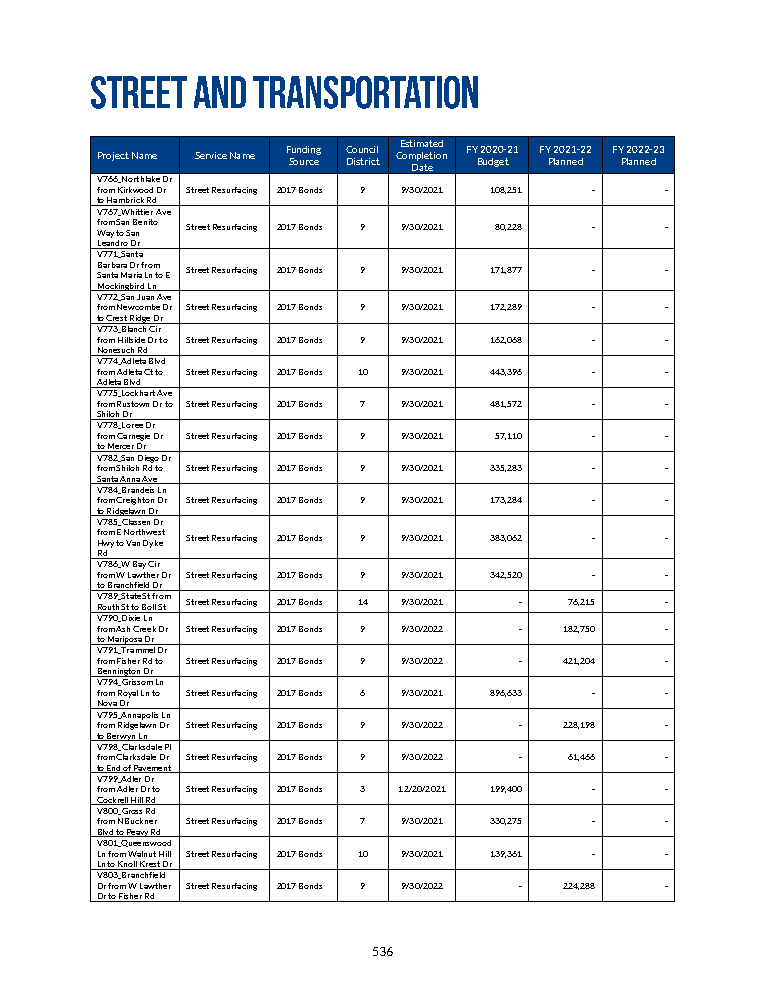

  Status   : OK

  Project  : 2211-2323 Deer Path Dr - 2905-3311 Kellogg Ave
  Dept     : SANITATION SERVICES  |  ID: V027
  Page     : 62  |  project_total: 0.0 ($K)
  Years    : {'year_2020': '0.0', 'year_2021': '503660.0', 'year_2022': '0.0'}


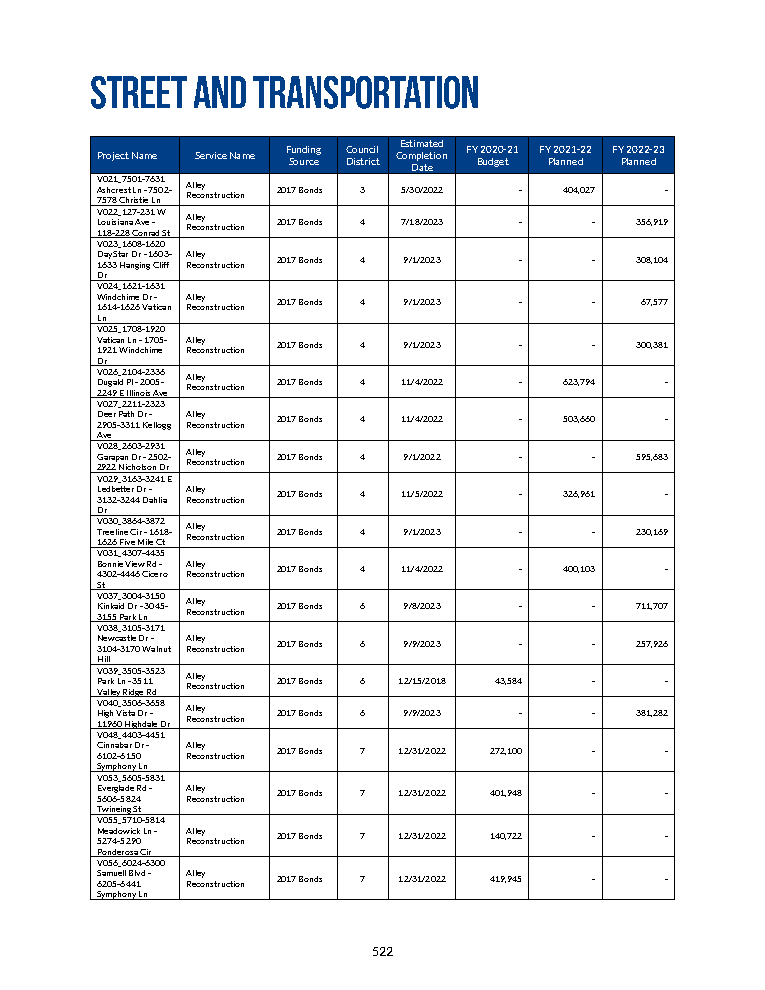

  Status   : OK

  Project  : Anzio Cir from Garapan Dr to S Polk St
  Dept     : SANITATION SERVICES  |  ID: V199
  Page     : 66  |  project_total: 0.0 ($K)
  Years    : {'year_2020': '0.0', 'year_2021': '243191.0', 'year_2022': '0.0'}


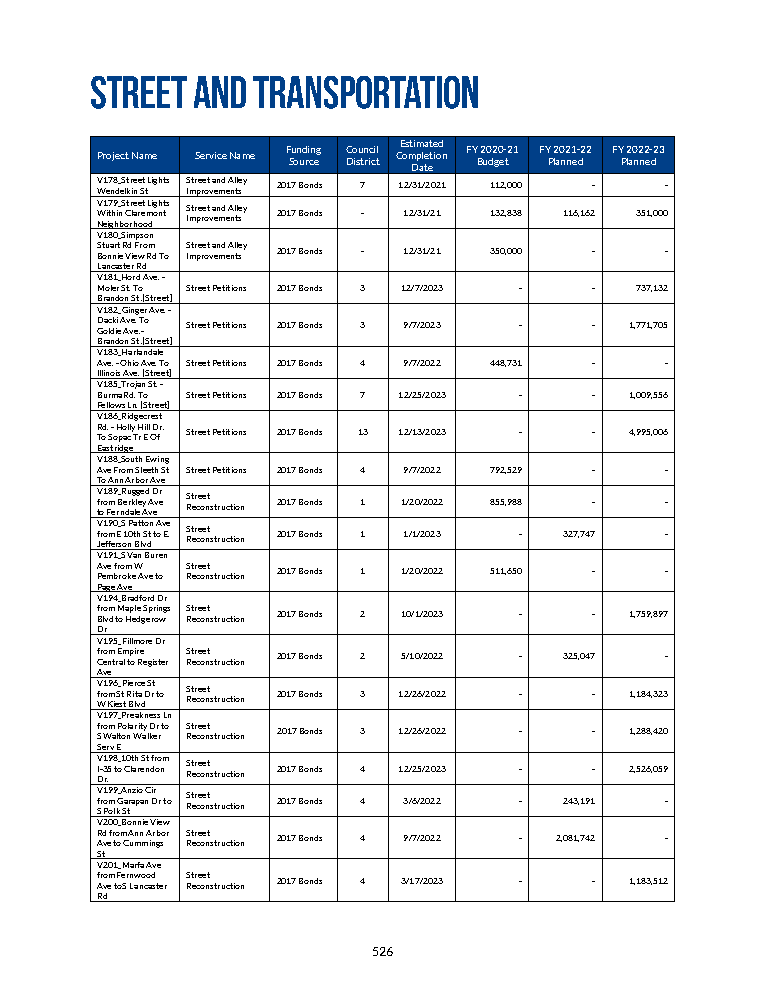

  Status   : OK

PDF: 2021.pdf  |  1631 projects  |  sampling 3  |  $K

  Project  : N V976 Hall Lemmon St McKinney to Ave - Ave from
  Dept     : ROADWAY PROJECTS THAT IMPROVE THE CAPACITY OF A SEGMENT OF ROADWAY BY  |  ID: nan
  Page     : 178  |  project_total: 155516.0 ($K)


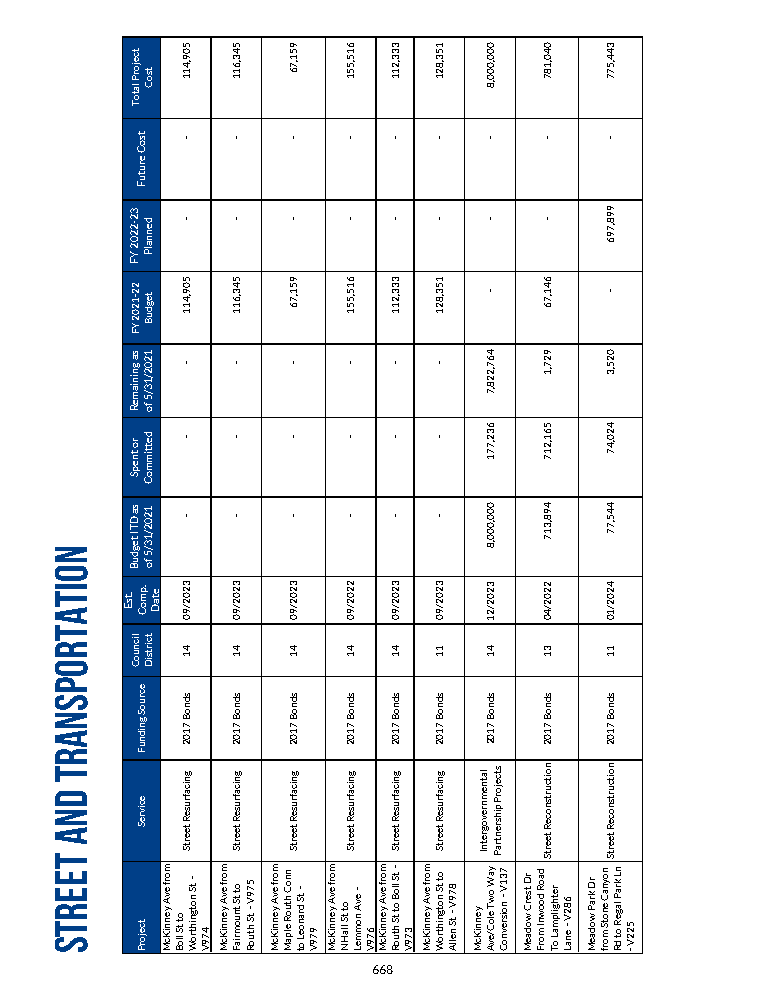

  Status   : OK

  Project  : Jim V204 Hodde Miller St Woodmont Rd - Dr from to N
  Dept     : ROADWAY PROJECTS THAT IMPROVE THE CAPACITY OF A SEGMENT OF ROADWAY BY  |  ID: nan
  Page     : 168  |  project_total: 1630432.0 ($K)


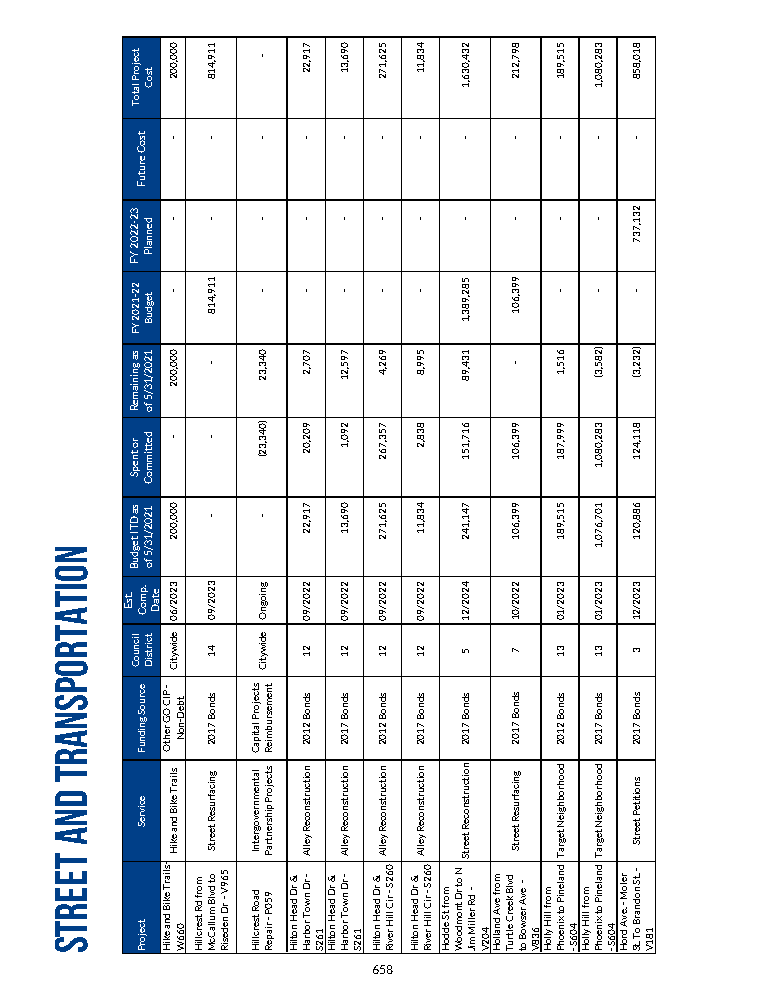

  Status   : OK

  Project  : To South South Lighting - Blvd Meadow St Central V176 From Expy
  Dept     : ROADWAY PROJECTS THAT IMPROVE THE CAPACITY OF A SEGMENT OF ROADWAY BY  |  ID: nan
  Page     : 193  |  project_total: 600053.0 ($K)


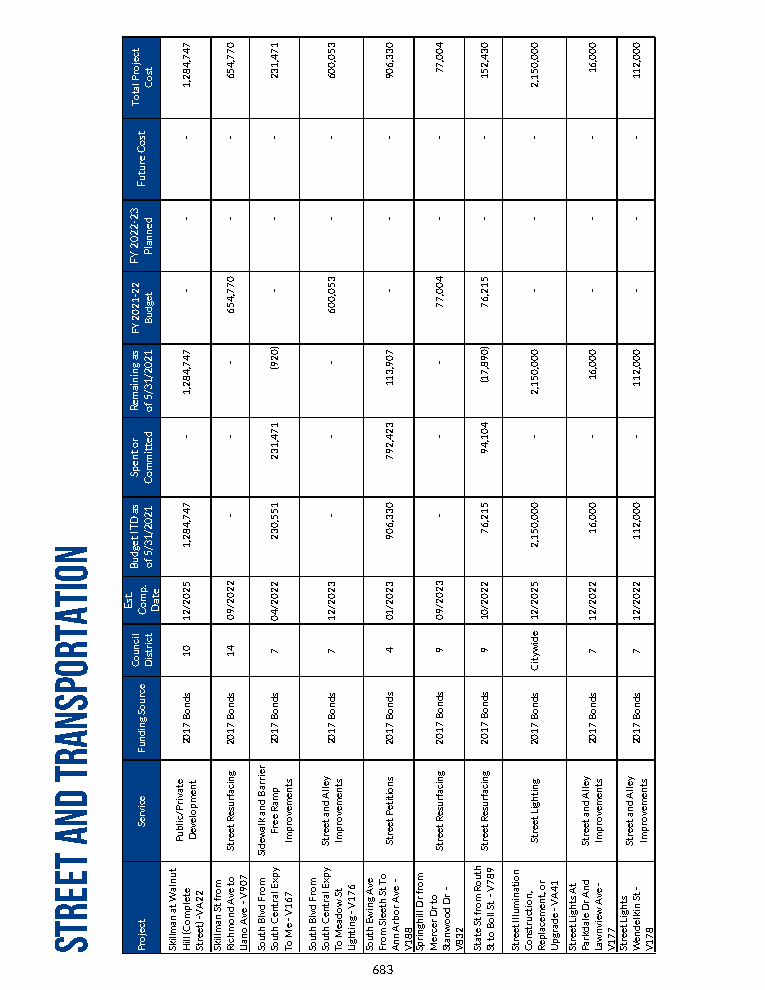

  Status   : OK

PDF: 2022.pdf  |  1536 projects  |  sampling 3  |  $K

  Project  : Imperial St From Bertrand Ave To Lagow S
  Dept     : SANITATION SERVICES  |  ID: S436
  Page     : 164  |  project_total: 29535.0 ($K)
  Years    : {'year_2022': '0.0', 'year_2023': '0.0'}


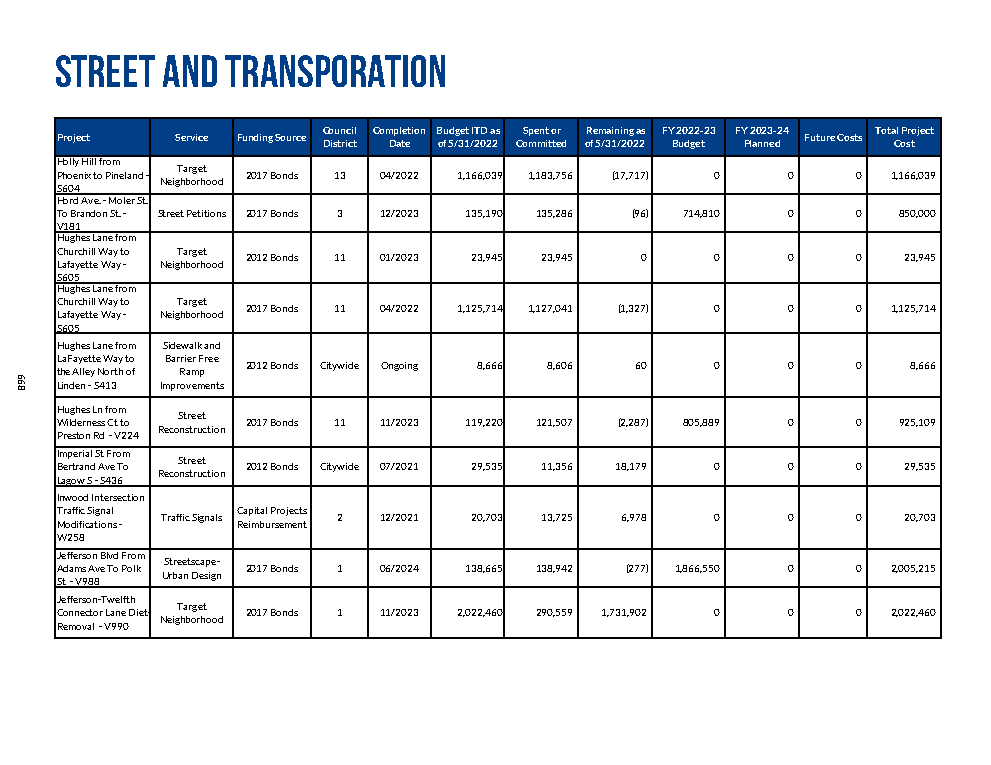

  Status   : OK

  Project  : Enterprise Electronic Document Management
  Dept     : WATER PUBLIC ARTS FUND  |  ID: E389
  Page     : 28  |  project_total: 725000.0 ($K)
  Years    : {'year_2022': '0.0', 'year_2023': '0.0'}


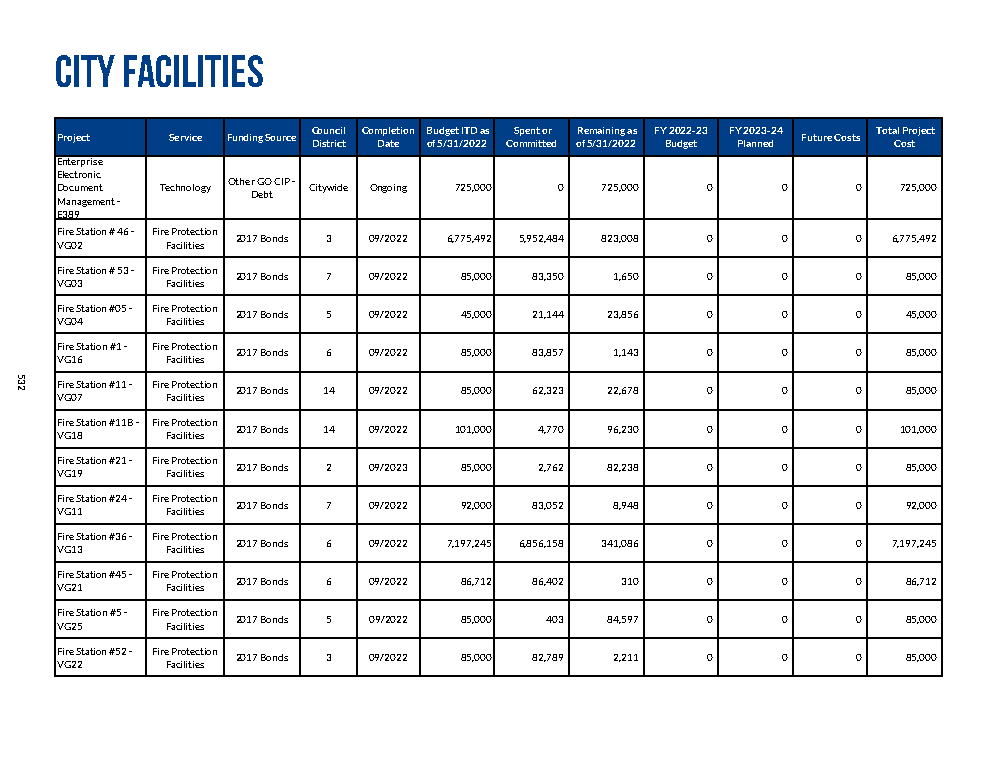

  Status   : OK

  Project  : Redevelopment of Grocery Store- 3035 N. Buckner
  Dept     : CONVENTION AND EVENT SERVICES  |  ID: VI30
  Page     : 62  |  project_total: 650000.0 ($K)
  Years    : {'year_2022': '0.0', 'year_2023': '0.0'}


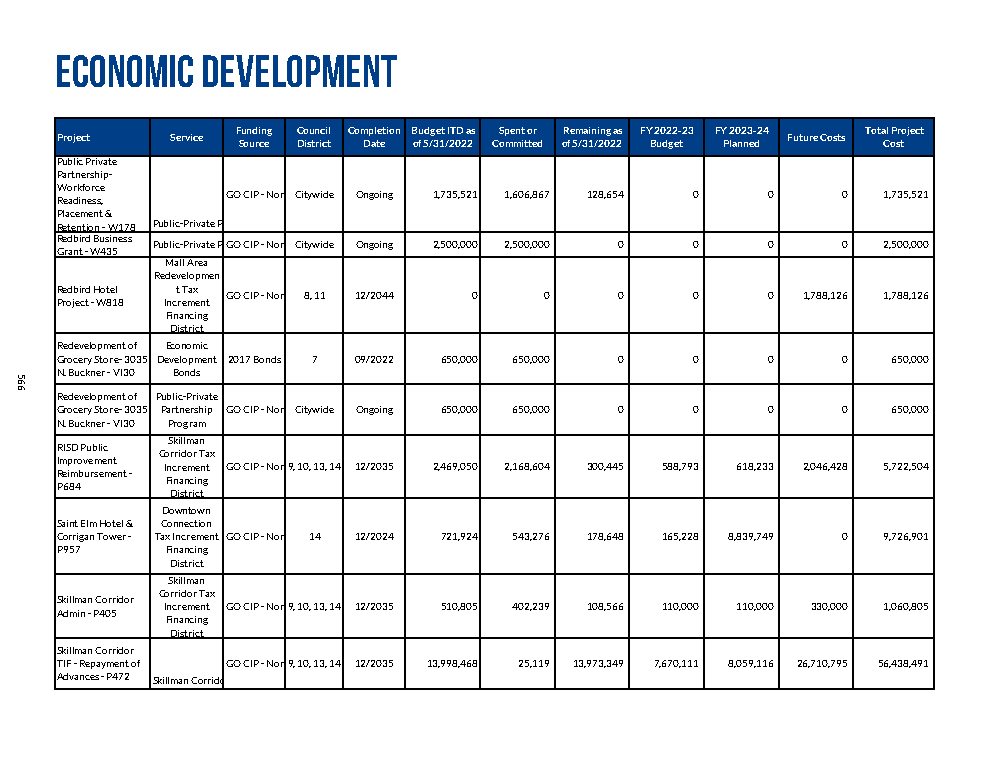

  Status   : OK

PDF: 2023.pdf  |  247 projects  |  sampling 3  |  $K

  Project  : Cedar Creek Bridge @ Clarendon (Sta 149+13)
  Dept     : FLOOD PROTECTION AND STORM DRAINAGE MANAGEMENT  |  ID: W718
  Page     : 84  |  project_total: 2215000.0 ($K)
  Years    : {'year_2023': '0.0', 'year_2024': '0.0'}


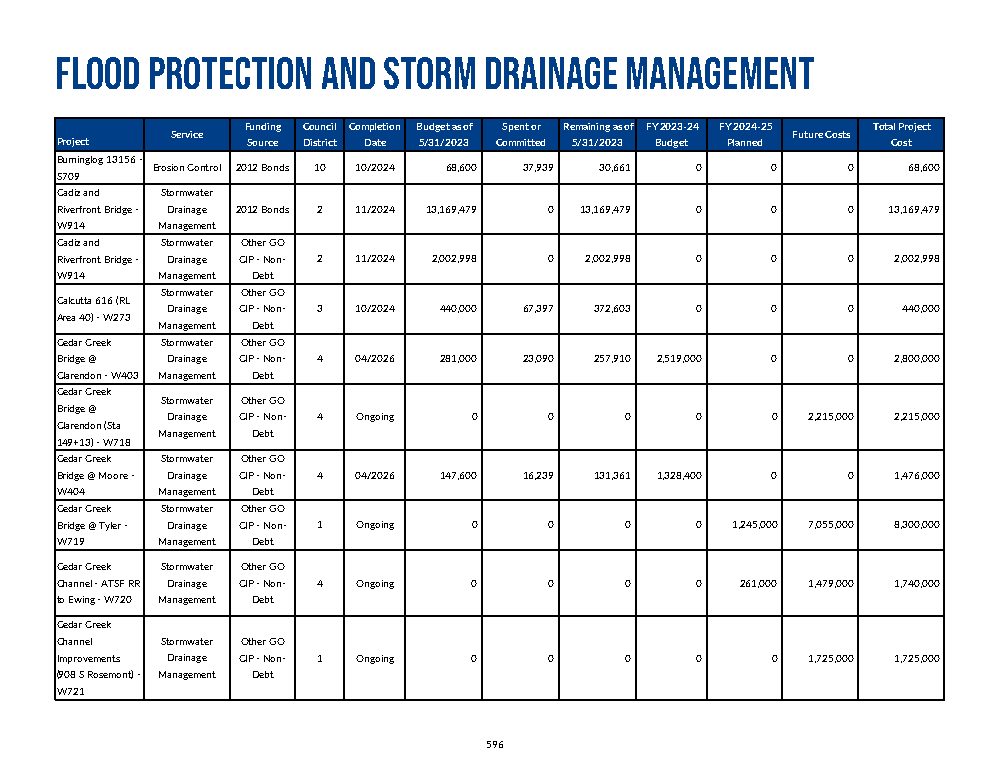

  Status   : OK

  Project  : 2133 Province
  Dept     : FLOOD PROTECTION AND STORM DRAINAGE MANAGEMENT  |  ID: W707
  Page     : 81  |  project_total: 575000.0 ($K)
  Years    : {'year_2023': '0.0', 'year_2024': '0.0'}


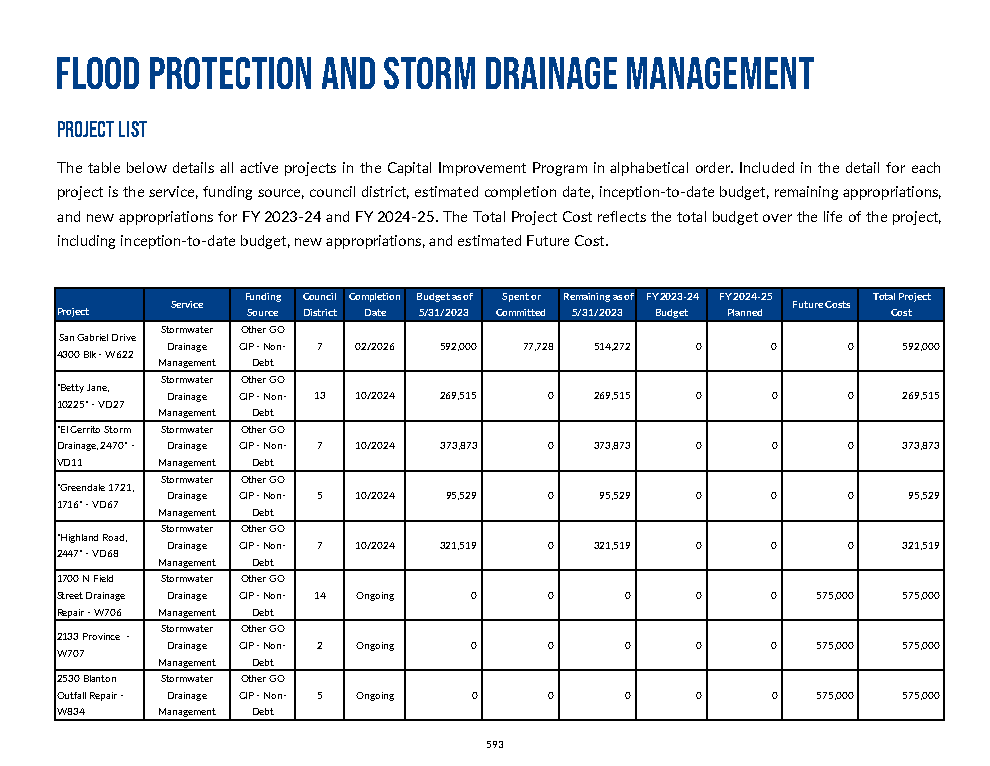

  Status   : OK

  Project  : Parrish Branch Culvert @ Wheatland Rd.
  Dept     : FLOOD PROTECTION AND STORM DRAINAGE MANAGEMENT  |  ID: W237
  Page     : 99  |  project_total: 562536.0 ($K)
  Years    : {'year_2023': '0.0', 'year_2024': '0.0'}


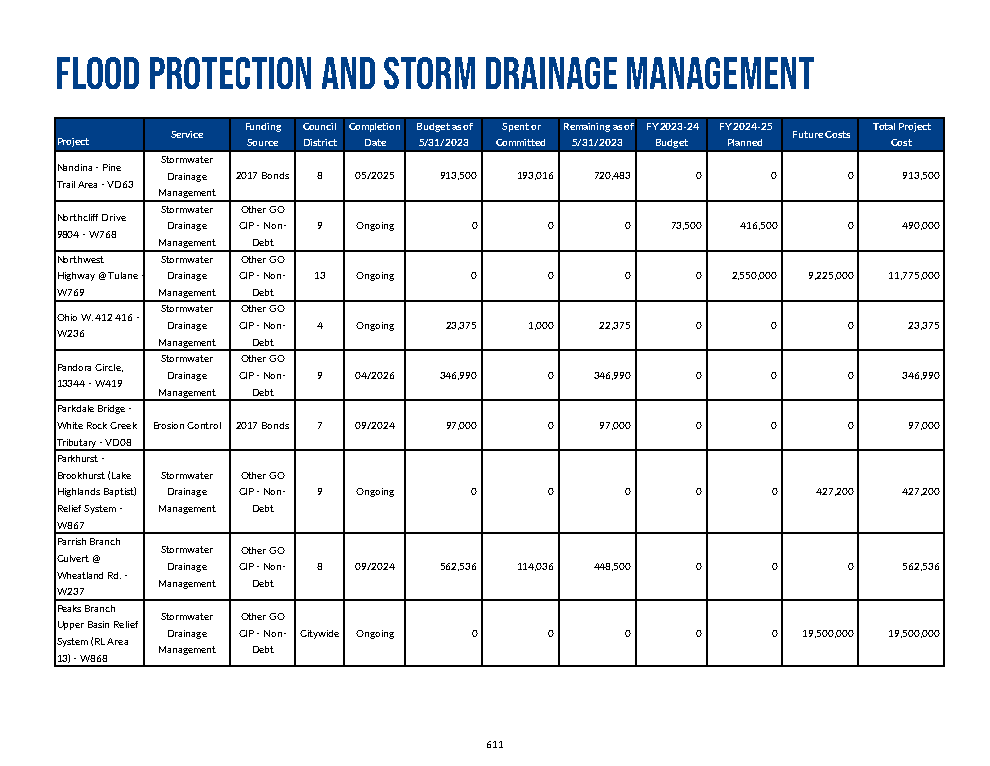

  Status   : OK

PDF: 2024.pdf  |  1710 projects  |  sampling 3  |  $K

  Project  : 3200 Little River Dr
  Dept     : STREET AND TRANSPORTATION  |  ID: Y257
  Page     : 146  |  project_total: 268351.0 ($K)
  Years    : {'year_2024': '0.0', 'year_2025': '268351.0'}


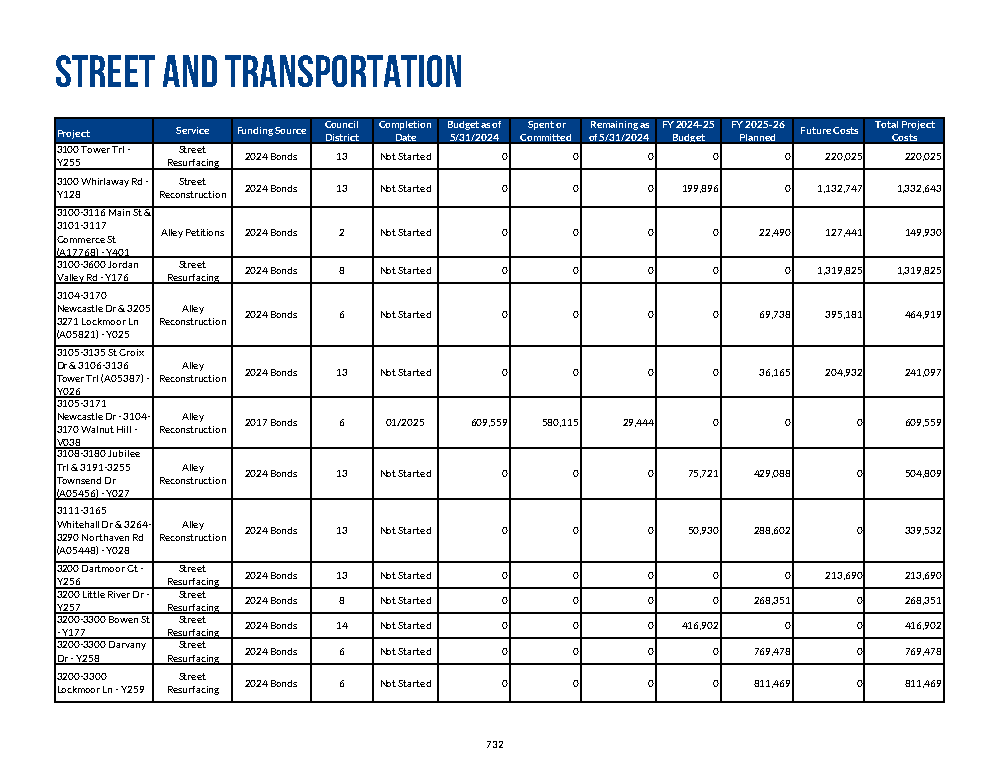

  Status   : OK

  Project  : East Side Water Tr Pl - Fa
  Dept     : WATER UTILITIES FACILITIES  |  ID: CW32
  Page     : 188  |  project_total: 3000000.0 ($K)
  Years    : {'year_2024': '0.0', 'year_2025': '0.0'}


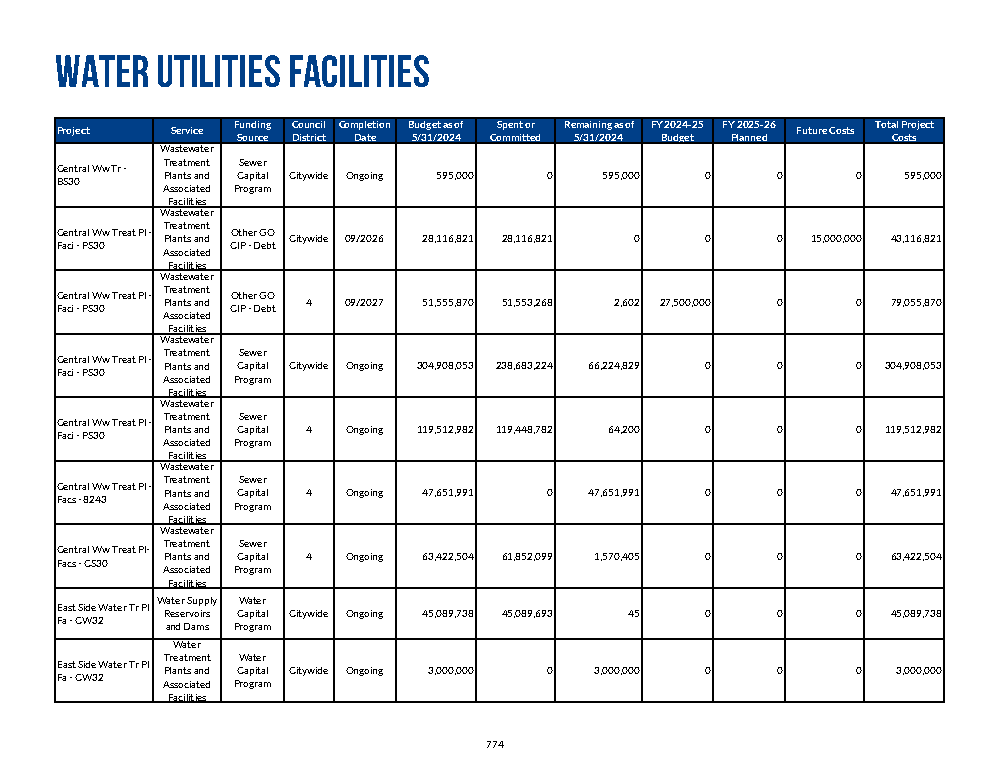

  Status   : OK

  Project  : TBD - CD14 Street Proposition Projects
  Dept     : STREET AND TRANSPORTATION  |  ID: Y475
  Page     : 179  |  project_total: 100000.0 ($K)
  Years    : {'year_2024': '0.0', 'year_2025': '0.0'}


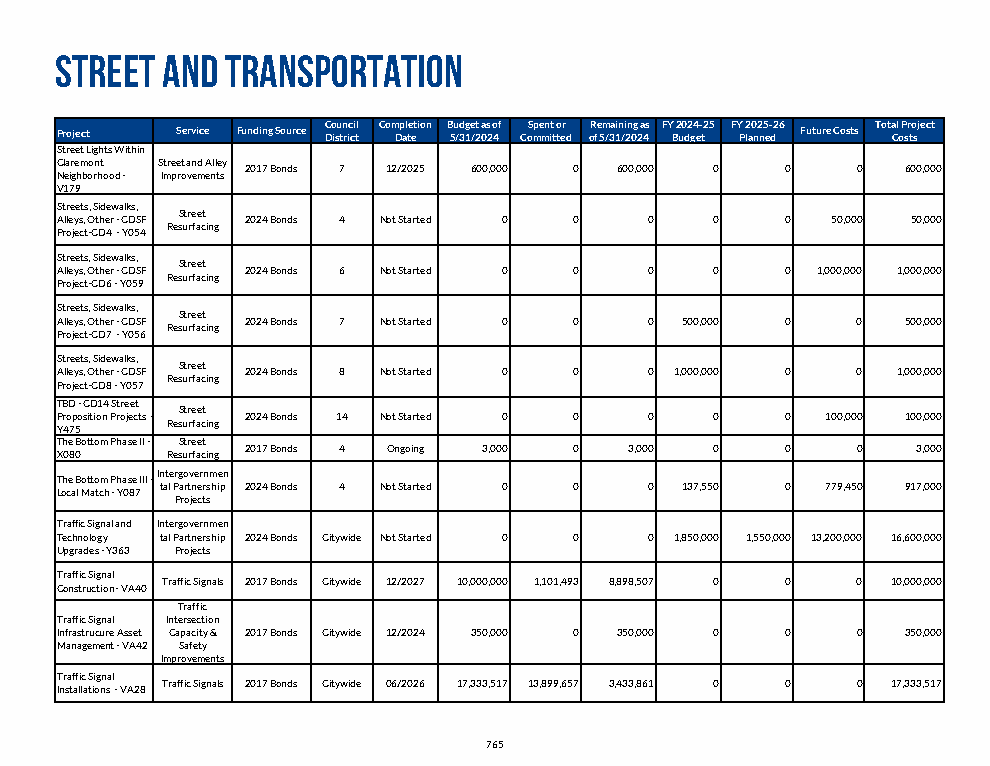

  Status   : OK

PDF: 2025.pdf  |  2187 projects  |  sampling 3  |  $K

  Project  : La Vista - Paulus To Gaston
  Dept     : STREET AND TRANSPORTATION  |  ID: Y068
  Page     : 180  |  project_total: 1100000.0 ($K)
  Years    : {'year_2025': '165000.0', 'year_2026': '935000.0'}


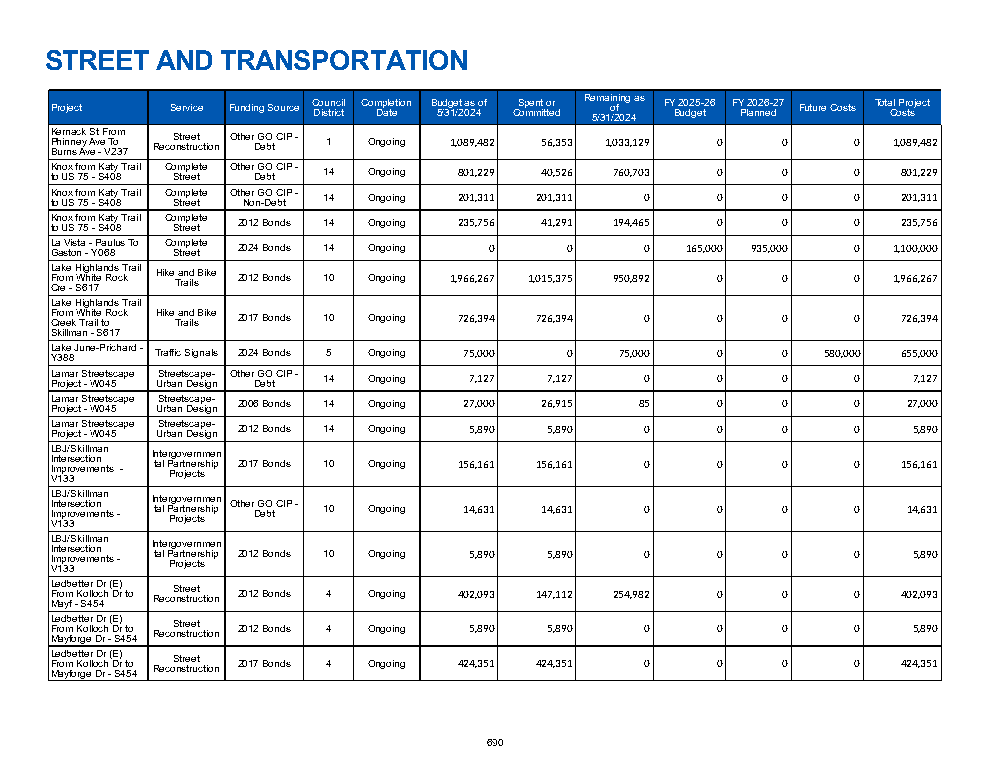

  Status   : OK

  Project  : 3004-3150 Kinkaid Dr & 3045-3155 Park Ln
  Dept     : STREET AND TRANSPORTATION  |  ID: V037
  Page     : 147  |  project_total: 5890.0 ($K)
  Years    : {'year_2025': '0.0', 'year_2026': '0.0'}


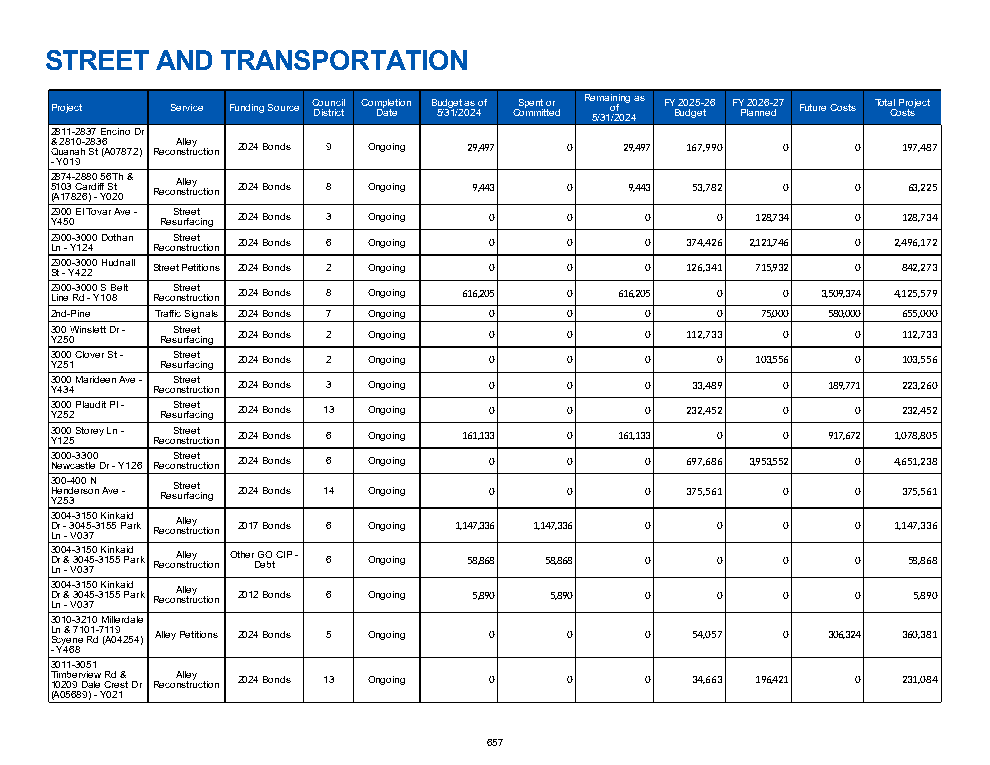

  Status   : OK

  Project  : Nutwood Cir. 6402
  Dept     : FLOOD PROTECTION AND STORM DRAINAGE MANAGEMENT  |  ID: YC13
  Page     : 92  |  project_total: 201251.0 ($K)
  Years    : {'year_2025': '0.0', 'year_2026': '171063.0'}


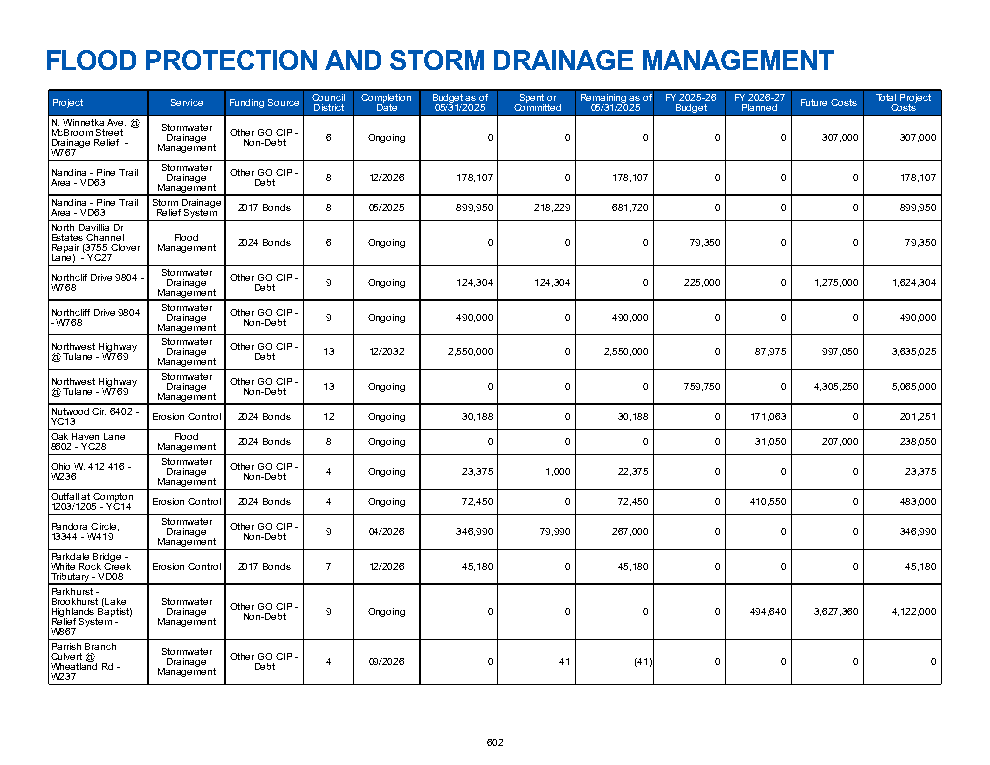

  Status   : OK


Check complete. Total issues flagged: 0


In [53]:
from IPython.display import display, Image as IPImage

CHECK_N        = 3
CHECK_SEED     = 42
check_findings = []

for p in sorted(PDF_DIR.glob('*.pdf')):
    stem     = p.stem
    csv_path = CSV_DIR / f'{stem}.csv'
    if not csv_path.exists():
        check_findings.append({'pdf': p.name, 'currency_unit': '', 'checks': [],
                               'note': 'CSV not found — run Cell 10 first'})
        continue

    df = pd.read_csv(csv_path, dtype=str)
    if len(df) == 0:
        check_findings.append({'pdf': p.name, 'currency_unit': '', 'checks': [],
                               'note': 'CSV is empty'})
        continue

    unit_label = currency_units.get(stem, ('$K', 1_000))[0]
    sample     = df.sample(min(CHECK_N, len(df)), random_state=CHECK_SEED)
    pdf_entry  = {'pdf': p.name, 'currency_unit': unit_label, 'checks': []}

    print(f"\n{'='*70}")
    print(f"PDF: {p.name}  |  {len(df)} projects  |  sampling {len(sample)}  |  {unit_label}")
    print('='*70)

    with pdfplumber.open(p) as pdf_obj:
        for _, row in sample.iterrows():
            proj_name  = str(row.get('project_name',  '') or '').strip()
            proj_total = str(row.get('project_total', '') or '').strip()
            dept       = str(row.get('department',    '') or '').strip()
            pid        = str(row.get('project_id',    '') or '').strip()
            try:
                pg_num = int(float(row.get('source_page', '')))
            except (ValueError, TypeError):
                pg_num = None

            print(f"\n  Project  : {proj_name}")
            print(f"  Dept     : {dept}  |  ID: {pid}")
            print(f"  Page     : {pg_num}  |  project_total: {proj_total} ({unit_label})")

            yr_vals = {c: str(row.get(c, '') or '').strip()
                       for c in df.columns if c.startswith('year_')
                       and str(row.get(c, '') or '').strip() not in ('', 'nan')}
            if yr_vals:
                print(f"  Years    : {yr_vals}")

            issues = []

            if not proj_name or proj_name in ('nan', 'N/A'):
                issues.append('project_name is empty')
            if not proj_total or proj_total in ('nan', 'N/A', ''):
                issues.append('project_total is missing')
            if pg_num is None:
                issues.append('source_page is missing or non-numeric')
            elif pg_num < 1 or pg_num > len(pdf_obj.pages):
                issues.append(f'source_page {pg_num} out of range (PDF has {len(pdf_obj.pages)} pages)')

            if pg_num and 1 <= pg_num <= len(pdf_obj.pages):
                pg_obj = pdf_obj.pages[pg_num - 1]

                # Name-match: scan column 0 of every table on the page.
                # extract_text() is NOT used here because it merges adjacent columns
                # and returns text in wrong order for rotated pages (pitfall: multi-
                # column bleed and 90°/270° reordering both cause false negatives).
                name_frag  = re.sub(r'\s+', ' ', proj_name[:30]).strip().lower()
                found_name = False
                if name_frag:
                    for tbl in get_page_tables(pg_obj):
                        for tbl_row in tbl:
                            cell_val = re.sub(r'\s+', ' ', clean_cell(tbl_row[0] if tbl_row else '')).lower()
                            if name_frag in cell_val or cell_val in name_frag:
                                found_name = True
                                break
                        if found_name:
                            break
                    if not found_name:
                        issues.append(f'name fragment "{proj_name[:30]}" not found in col-0 of any table on page {pg_num}')

                # Render page as image for visual inspection
                if HAS_PIL:
                    try:
                        img_path = CSV_DIR / f'_check_{stem}_pg{pg_num:04d}.png'
                        pg_obj.to_image(resolution=90).save(str(img_path))
                        display(IPImage(str(img_path), width=620))
                    except Exception as e:
                        print(f"  [image render failed: {e}]")
                else:
                    print("  [install Pillow for inline page images: pip install Pillow]")

            print(f"  Status   : {'ISSUES' if issues else 'OK'}")
            for iss in issues:
                print(f"    *** {iss}")

            pdf_entry['checks'].append({
                'project_name':  proj_name,
                'project_id':    pid,
                'source_page':   pg_num,
                'project_total': proj_total,
                'issues':        issues,
            })

    check_findings.append(pdf_entry)

total_issues = sum(len(c['issues']) for f in check_findings for c in f.get('checks', []))
print(f"\n\nCheck complete. Total issues flagged: {total_issues}")

## Cell 12 - Write validation report

In [54]:
from datetime import date

report_path = CITY_DIR / 'check_report.md'

lines = [
    '# Dallas CIP Parser — Spot-Check Report\n\n',
    f'Generated: {date.today()}  |  Sample: {CHECK_N} projects per PDF\n\n',
]

total_ok     = 0
total_issues = 0

for entry in check_findings:
    unit   = entry.get('currency_unit', '')
    note   = entry.get('note', '')
    checks = entry.get('checks', [])
    lines.append(f"## {entry['pdf']}  ({unit})\n\n")
    if note:
        lines.append(f'*{note}*\n\n')
        continue
    for c in checks:
        pg    = c['source_page'] or 'N/A'
        pid   = f"  `{c['project_id']}`" if c['project_id'] else ''
        total = c['project_total']
        if c['issues']:
            status = 'ISSUES: ' + '; '.join(c['issues'])
            total_issues += len(c['issues'])
        else:
            status = 'OK'
            total_ok += 1
        lines.append(
            f"- **{c['project_name']}**{pid} (page {pg}, total {total}) -> {status}\n"
        )
    lines.append('\n')

lines.append('## Summary\n\n')
lines.append(f'- Projects checked OK : {total_ok}\n')
lines.append(f'- Issues flagged      : {total_issues}\n')
lines.append('\n## High null-rate columns (>50%)\n\n')

any_high = False
for s in all_summaries:
    if s.get('high_null'):
        lines.append(f"- **{s['pdf']}**: {s['high_null']}\n")
        any_high = True
if not any_high:
    lines.append('None.\n')

with open(report_path, 'w', encoding='utf-8') as fh:
    fh.writelines(lines)

print(f"Report written to: {report_path}")
print(f"  OK: {total_ok}  |  Issues: {total_issues}")

Report written to: C:\Users\vince\Documents\GitHub\CIPBD\Dallas\check_report.md
  OK: 54  |  Issues: 0
